# 05. The Calibrated Dirt Machine

**The question.** Can we build noise we can defend? Every controlled ER experiment downstream
of this notebook runs on synthetic corruption, and synthetic corruption is where ER papers
quietly smuggle in their conclusions: a generator that sprinkles uniform typos manufactures a
world where typo-robustness wins by construction. Notebook 04 measured what real two-year
record drift actually looks like (NSE-01); this notebook builds the generator that reproduces
that measurement, **channel by channel, rate by rate, with the provenance of every dial
printed** — then scores its own fidelity against the measurement with an audit that shares no
code with the generator (NSE-02), and constructs the leakage-controlled evaluation splits
(MET-07) every later notebook will train and evaluate on.

**What this notebook settles.** Four things: (1) an explicit, documented mapping from NSE-01
audit categories to generator channels, each rate traced to the artifact cell it came from;
(2) the calibrated corpus itself — `historical_50k` base, entity-complete, plus household
confusables and hub-value traps — registered as `calibrated_corpus` with its full ops log;
(3) NSE-02 fidelity: per-field diff-mix divergence of calibrated vs a budget-matched generic
uniform-typo baseline, plus the PLAN §4 acceptance criteria (surname Zipf tail, soundex
block-size distribution, collision mass) with pre-stated thresholds and an honest verdict;
(4) MET-07 split construction — random / entity-disjoint / household-disjoint — registered as
`met07_splits`, with a single-seed smoke demo of split optimism (the multi-seed verdict is
the mid-tier rerun of these same cells).

In [1]:
import time

import jellyfish
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.spatial.distance import jensenshannon
from scipy.stats import norm

from er_lab.blocking import matchkeys
from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.data.loaders import load_historical_50k
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.noise.audit import classify_pair_diffs
from er_lab.noise.channels import (
    PerRecordChannel,
    fetch_lexicon,
    field_dropout,
    get_cell,
    hub_value,
    load_lexicon,
    name_order_swap,
    nickname,
    ops_frame,
    typo,
)
from er_lab.noise.exposure import ExposureModel
from er_lab.noise.generate import generate_corpus, household_confusables
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v22-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

One size dial: how many **base records** the entity-complete `historical_50k` subsample
carries (whole clusters, never split — a split entity would corrupt every downstream recall
number). At smoke that is ~18k base records; at mid/target the full corpus. The split-optimism
demo runs one seed at smoke and the full `run.seeds` list at mid/target — same cells, only the
budgets move. Smoke budget for this whole notebook: **<= ~20 min on the 4-CPU container**
(wall-clock printed and measured at the end).

In [3]:
TIER = str(cfg.run.tier)
SIZES = {"smoke": 18_000, "mid": None, "target": None, "analytical": 18_000}  # base records
DEMO_N = {"smoke": 8_000, "mid": 20_000, "target": 20_000, "analytical": 8_000}[TIER]
DEMO_BASE_RATE = 0.05  # exposure-demo base rate — deliberately inflated for count visibility
HH_RATE = 0.05  # household-confusable spawn rate per base record — GENERIC (trap, not measured)
HUB_RATE = 0.01  # hub-value trap rate per duplicate — GENERIC (trap, not measured)
PRIMARY_SEED = int(cfg.run.seed)
SEEDS_DEMO = (
    [PRIMARY_SEED] if TIER in ("smoke", "analytical") else [int(s) for s in cfg.run.seeds]
)
print(f"tier={TIER}: base-record budget = {SIZES.get(TIER)}, "
      f"split-demo seeds = {SEEDS_DEMO}, smoke budget <= ~20 min")

tier=smoke: base-record budget = 18000, split-demo seeds = [17], smoke budget <= ~20 min


## 1. What did reality do? The targets this machine must hit

Everything below calibrates against notebook 04's registered artifacts — loaded through the
registry, tier-checked, never re-derived here. Three targets:

- `nse01_channel_prevalence` — the measured per-field × per-category diff mix (the rates);
- `nse01_address_cochange` — the jointness of address change (moves are events, not columns);
- `nse01_exposure_model` — per-group multipliers on the name-change channels.

The prevalence artifact's registered caveat is reprinted verbatim below because every rate in
this notebook inherits it: these are **two-year change rates on stable registrants**, not
entry-error rates — a typo present in both snapshots was invisible to the audit, so typo-like
channels are calibrated to *lower bounds*. (`nse01_address_cochange` and `corpus_registry`
are supporting/upstream artifacts of notebooks 04 and 01 — not in this notebook's declared
`requires`, but guaranteed present whenever `nse01_channel_prevalence` exists, and loaded with
the same hard-fail placard semantics.)

In [4]:
prev, prev_meta = registry.load("nse01_channel_prevalence", tier=cfg.run.tier)
CAVEAT = str(prev_meta["extra"]["caveat"])
AUDIT_SCOPE = str(prev_meta["extra"]["scope"])
N_AUDIT_PAIRS = int(prev_meta["extra"]["pairs_audited"])
PREV_PROVENANCE = (
    f"nse01_channel_prevalence run {prev_meta['created_at']} "
    f"(cfg {prev_meta['config_hash']}, tier {prev_meta['tier']}, scope {AUDIT_SCOPE}, "
    f"{N_AUDIT_PAIRS} audited pairs)"
)
print(f"calibration source: {PREV_PROVENANCE}\n")
print(f"registered caveat (inherited by every artifact below):\n  {CAVEAT}\n")
changes = prev[prev["category"] != "identical"].reset_index(drop=True)
print(f"{len(prev)} (field x category) rows; the {len(changes)} change rows:")
display(changes)

calibration source: nse01_channel_prevalence run 2026-08-29T15:42:06.789133+00:00 (cfg 129c9d9243ca, tier smoke, scope county_subset_subsample, 120000 audited pairs)

registered caveat (inherited by every artifact below):
  Same-NCID diffs across two snapshots measure CHANGES over the elapsed window — moves, legal name changes (marriage/divorce), clerical corrections, coding drift — NOT raw entry-error rates. An entry error is visible only when exactly one snapshot carries it; an error stable across both snapshots is invisible by construction. These rates calibrate the temporal-drift noise axis directly and bound typo/OCR entry-error channels only from below. Substrate selection (NB03 sec 2b): duplicated ncids are excluded, biasing the substrate toward stable registrants — every rate is a lower bound for mobile subpopulations.

39 (field x category) rows; the 30 change rows:


,field,category,n,rate,ci_low,ci_high,scope
0,city,wholesale,610,0.005083,0.004697,0.005502,county_subset_subsample
1,family_name,format_drift,186,0.001550,0.001343,0.001789,county_subset_subsample
2,family_name,swap,4,0.000033,0.000013,0.000086,county_subset_subsample
3,family_name,typo,23,0.000192,0.000128,0.000288,county_subset_subsample
4,family_name,wholesale,152,0.001267,0.001081,0.001485,county_subset_subsample
5,given_name,format_drift,43,0.000358,0.000266,0.000483,county_subset_subsample
6,given_name,missing_loss,1,0.000008,0.000001,0.000047,county_subset_subsample
7,given_name,nickname,10,0.000083,0.000045,0.000153,county_subset_subsample
8,given_name,swap,4,0.000033,0.000013,0.000086,county_subset_subsample
9,given_name,typo,31,0.000258,0.000182,0.000367,county_subset_subsample


In [5]:
cochange, cochange_meta = registry.load("nse01_address_cochange", tier=cfg.run.tier)
print("address jointness (P(event | condition) vs unconditional baseline) — moves are events:")
display(cochange[["condition", "event", "k", "n", "rate", "baseline_rate"]])

exposure_tbl, exposure_meta = registry.load("nse01_exposure_model", tier=cfg.run.tier)
print("\nmeasured exposure multipliers, family_name_change channel:")
display(exposure_tbl[exposure_tbl["channel"] == "family_name_change"]
        [["group_col", "group", "n", "k", "rate", "multiplier"]])

address jointness (P(event | condition) vs unconditional baseline) — moves are events:


,condition,event,k,n,rate,baseline_rate
0,street changed,zip changed,1017,1838,0.553319,0.008533
1,street changed,city changed,604,1838,0.328618,0.005083
2,street changed,house_number changed,1803,1838,0.980958,0.016058
3,zip changed,street changed,1017,1024,0.993164,0.015317
4,family_name wholesale,given_name changed,12,152,0.078947,0.001142
5,family_name wholesale,street changed,33,152,0.217105,0.015317



measured exposure multipliers, family_name_change channel:


,group_col,group,n,k,rate,multiplier
0,race,W,92443,100,0.001082,0.854011
1,race,B,13588,19,0.001398,1.103915
2,race,U,6107,19,0.003111,2.456198
3,race,O,3292,11,0.003341,2.637974
4,race,A,3231,2,0.000619,0.488687
5,race,M,1064,1,0.000940,0.741987
6,race,I,275,0,0.000000,0.000000
7,sex,F,63107,118,0.001870,1.476190
8,sex,M,51694,17,0.000329,0.259625
9,sex,U,5199,17,0.003270,2.581468


## 2. From audit bins to generator dials: the mapping

The audit speaks in per-field diff categories; the generator speaks in per-record channel
rates. The bridge is an explicit mapping, one row per channel, each rate traced to the
artifact cell(s) it came from. The aggregation rules, stated once:

- **typo → `typo`** (per field): the measured `typo` rate on each name field, one channel
  instance per field so the per-field profile survives. `zip:typo` and `house_number:typo`
  are **excluded** — notebook 04 §6 showed those bins are near-moves in disguise, not
  keyboard errors; their mass is routed to the move channels below.
- **nickname → `nickname`**: `given_name:nickname`, lexicon-driven, case-preserving.
- **swap → `name_order_swap`**: a swap event lands in *both* participating fields' bins, so
  the event rate is the **mean** of `given_name:swap` and `family_name:swap` (the
  given↔middle portion has no counterpart here — historical_50k has no middle name).
- **missing_gain/loss → `field_dropout`** (per field): gain+loss folded into one mass per
  field (a generator can only *drop* — orientation is folded symmetrically in the fidelity
  audit too). Only fields with measured missing mass get a channel.
- **format_drift → `field_format_drift`** for the fields the package channel handles
  (dob/street/phone): **zero measured mass** on this corpus's counterparts — notebook 04
  showed within-source format volatility is essentially nil (it is a cross-source
  phenomenon, PRS-01's factor) — so the package channel is *omitted, rate 0, documented*.
  The measured name-field `format_drift` mass (case/punctuation skeleton changes) is
  carried by a small custom `name_format_drift` channel instead (§4).
- **wholesale on address → `move`** (custom): a joint redraw of (`city`, `zip`) from the
  corpus value pool at the `city:wholesale` rate, plus a `zip`-only redraw carrying the
  *excess* zip-change mass (`zip:wholesale + zip:typo − city:wholesale` — within-city moves
  change zip but not city). This respects both fields' marginal change rates AND the
  jointness in `nse01_address_cochange`; summing the per-field rates would double-count the
  same move.
- **wholesale on name fields → `name_change`** (custom): per-field redraw from the corpus
  name pool at the measured wholesale rates — the legal-name-change channel the exposure
  model is fitted on. `full_name` is kept consistent (§4).
- **Traps, generic and labeled:** `hub_value` and `household_confusables` inject the
  chain-merge pathologies (lit_review §3) at rates the audit *cannot* measure — both are
  labeled GENERIC in the table and in the corpus meta, never presented as measured.
- **Unmeasurable here, excluded, said out loud:** OCR and phonetic-respelling channels have
  no audit bin (a stable entry error is invisible to a two-snapshot diff). Notebook 04's
  closing suggested generic literature defaults for entry-error channels; this notebook
  instead keeps the **measured floors** so that every dial in `calibrated_corpus` is
  defendable by measurement — the generic-dose entry-error contrast is exactly TRN-03's
  augmentation dial and NSE-03's ranking-invariance question, where it is the experimental
  variable rather than a buried constant. The lower-bound caveat rides in the meta.

In [6]:
def audit_cell(field: str, category: str) -> tuple[float, int]:
    """(rate, n) of one prevalence cell; (0.0, 0) when the audit observed no such event."""
    row = prev[(prev["field"] == field) & (prev["category"] == category)]
    if len(row) == 0:
        return 0.0, 0
    return float(row["rate"].iloc[0]), int(row["n"].iloc[0])


def cells_str(*cells: tuple[str, str]) -> str:
    parts = []
    for f, c in cells:
        r, n = audit_cell(f, c)
        parts.append(f"{f}:{c}={r:.6f} (n={n})")
    return " + ".join(parts)


r_move = audit_cell("city", "wholesale")[0]
r_zip_only = max(
    0.0, audit_cell("zip", "wholesale")[0] + audit_cell("zip", "typo")[0] - r_move
)
CH_RATE = {
    "move": r_move,
    "move_zip_only": r_zip_only,
    "name_change_family": audit_cell("family_name", "wholesale")[0],
    "name_change_given": audit_cell("given_name", "wholesale")[0],
    "name_format_drift_family": audit_cell("family_name", "format_drift")[0],
    "name_format_drift_given": audit_cell("given_name", "format_drift")[0],
    "typo_family": audit_cell("family_name", "typo")[0],
    "typo_given": audit_cell("given_name", "typo")[0],
    "nickname": audit_cell("given_name", "nickname")[0],
    "name_order_swap": 0.5 * (audit_cell("given_name", "swap")[0]
                              + audit_cell("family_name", "swap")[0]),
    "dropout_given": (audit_cell("given_name", "missing_gain")[0]
                      + audit_cell("given_name", "missing_loss")[0]),
    "dropout_family": (audit_cell("family_name", "missing_gain")[0]
                       + audit_cell("family_name", "missing_loss")[0]),
    "dropout_city": (audit_cell("city", "missing_gain")[0]
                     + audit_cell("city", "missing_loss")[0]),
    "dropout_zip": (audit_cell("zip", "missing_gain")[0]
                    + audit_cell("zip", "missing_loss")[0]),
    "hub_value": HUB_RATE,
}
rate_rows = [
    ("move", "move", "city+zip (joint)", "measured",
     "city:wholesale rate (joint-event rule; see mapping)", cells_str(("city", "wholesale"))),
    ("move_zip_only", "move", "zip", "measured",
     ("zip:wholesale + zip:typo - city:wholesale (excess = within-city moves; "
      "zip:typo is near-moves per NB04 sec 6, NOT keyboard error)"),
     cells_str(("zip", "wholesale"), ("zip", "typo"), ("city", "wholesale"))),
    ("name_change_family", "name_change", "family_name", "measured",
     "family_name:wholesale (legal-name-change channel)",
     cells_str(("family_name", "wholesale"))),
    ("name_change_given", "name_change", "given_name", "measured",
     "given_name:wholesale", cells_str(("given_name", "wholesale"))),
    ("name_format_drift_family", "name_format_drift", "family_name", "measured",
     "family_name:format_drift (custom case/punct channel; package channel lacks name fields)",
     cells_str(("family_name", "format_drift"))),
    ("name_format_drift_given", "name_format_drift", "given_name", "measured",
     "given_name:format_drift", cells_str(("given_name", "format_drift"))),
    ("typo_family", "typo", "family_name", "measured",
     "family_name:typo (LOWER BOUND per registered caveat)",
     cells_str(("family_name", "typo"))),
    ("typo_given", "typo", "given_name", "measured",
     "given_name:typo (LOWER BOUND per registered caveat)", cells_str(("given_name", "typo"))),
    ("nickname", "nickname", "given_name", "measured",
     "given_name:nickname", cells_str(("given_name", "nickname"))),
    ("name_order_swap", "name_order_swap", "given_name+family_name", "measured",
     "mean of given/family swap bins (one event fills both bins)",
     cells_str(("given_name", "swap"), ("family_name", "swap"))),
    ("dropout_given", "field_dropout", "given_name", "measured",
     "given_name missing_gain+missing_loss folded",
     cells_str(("given_name", "missing_gain"), ("given_name", "missing_loss"))),
    ("dropout_family", "field_dropout", "family_name", "measured",
     "family_name missing mass (zero observed -> channel omitted)",
     cells_str(("family_name", "missing_gain"), ("family_name", "missing_loss"))),
    ("dropout_city", "field_dropout", "city", "measured",
     "city missing mass (zero observed -> channel omitted)",
     cells_str(("city", "missing_gain"), ("city", "missing_loss"))),
    ("dropout_zip", "field_dropout", "zip", "measured",
     "zip missing mass (zero observed -> channel omitted)",
     cells_str(("zip", "missing_gain"), ("zip", "missing_loss"))),
    ("field_format_drift", "field_format_drift", "dob", "measured",
     ("no measured counterpart cell (within-source format drift ~ absent, NB04 sec 6) -> "
      "rate 0, channel omitted"), "none observed"),
    ("ocr", "ocr", "-", "unmeasurable-here",
     ("no audit bin: stable entry errors invisible to two-snapshot diffs -> excluded; "
      "generic-dose entry error is TRN-03's dial"), "-"),
    ("phonetic_spelling", "phonetic_spelling", "-", "unmeasurable-here",
     "no audit bin (same reason as ocr) -> excluded", "-"),
    ("hub_value", "hub_value", "dob", "generic-trap",
     f"chain-merge pathology injector at {HUB_RATE} per duplicate — NOT measured",
     "-"),
    ("household_confusables", "household", "given_name/dob (+new entity)", "generic-trap",
     f"co-resident trap negatives at {HH_RATE} per base record — NOT measured", "-"),
]
rates_tbl = pd.DataFrame(
    rate_rows, columns=["channel_key", "ops_channel", "corpus_fields", "basis", "rule",
                        "source_cells"]
)
rates_tbl["rate"] = [
    float(CH_RATE.get(k, HH_RATE if k == "household_confusables" else 0.0))
    for k in rates_tbl["channel_key"]
]
rates_tbl["included"] = [
    (r > 0) if b == "measured" else (b == "generic-trap")
    for r, b in zip(rates_tbl["rate"], rates_tbl["basis"])
]
GENERIC_TYPO_RATE = float(
    rates_tbl.loc[rates_tbl["basis"] == "measured", "rate"].sum()
)
registry.register(
    "calibrated_channel_rates", rates_tbl, cfg=cfg, tier=cfg.run.tier,
    meta={"provenance": PREV_PROVENANCE, "caveat": CAVEAT,
          "generic_typo_budget": GENERIC_TYPO_RATE,
          "note": "one row per channel; 'rate' is per-duplicate-record probability; "
                  "'source_cells' names the exact nse01_channel_prevalence cells"},
)
pd.set_option("display.max_colwidth", 110)
display(rates_tbl[["channel_key", "corpus_fields", "rate", "basis", "included",
                   "source_cells", "rule"]])
print(f"generic uniform-typo budget (= sum of measured audit-mapped rates, the matched "
      f"per-record edit budget for the baseline arm): {GENERIC_TYPO_RATE:.6f}")

,channel_key,corpus_fields,rate,basis,included,source_cells,rule
0,move,city+zip (joint),0.005083,measured,True,city:wholesale=0.005083 (n=610),city:wholesale rate (joint-event rule; see mapping)
1,move_zip_only,zip,0.003450,measured,True,zip:wholesale=0.002200 (n=264) + zip:typo=0.006333 (n=760) + city:wholesale=0.005083 (n=610),zip:wholesale + zip:typo - city:wholesale (excess = within-city moves; zip:typo is near-moves per NB04 sec...
2,name_change_family,family_name,0.001267,measured,True,family_name:wholesale=0.001267 (n=152),family_name:wholesale (legal-name-change channel)
3,name_change_given,given_name,0.000400,measured,True,given_name:wholesale=0.000400 (n=48),given_name:wholesale
4,name_format_drift_family,family_name,0.001550,measured,True,family_name:format_drift=0.001550 (n=186),family_name:format_drift (custom case/punct channel; package channel lacks name fields)
5,name_format_drift_given,given_name,0.000358,measured,True,given_name:format_drift=0.000358 (n=43),given_name:format_drift
6,typo_family,family_name,0.000192,measured,True,family_name:typo=0.000192 (n=23),family_name:typo (LOWER BOUND per registered caveat)
7,typo_given,given_name,0.000258,measured,True,given_name:typo=0.000258 (n=31),given_name:typo (LOWER BOUND per registered caveat)
8,nickname,given_name,0.000083,measured,True,given_name:nickname=0.000083 (n=10),given_name:nickname
9,name_order_swap,given_name+family_name,0.000033,measured,True,given_name:swap=0.000033 (n=4) + family_name:swap=0.000033 (n=4),mean of given/family swap bins (one event fills both bins)


generic uniform-typo budget (= sum of measured audit-mapped rates, the matched per-record edit budget for the baseline arm): 0.012683


## 3. The conjecture, before any corruption runs

The fidelity claim, pre-registered: rate calibration should beat rate folklore *measurably*.
Both arms get the same base records, the same duplicate structure, the same seed, and the
same total per-record edit budget — the generic arm just spends it the way generic generators
do (one uniform typo channel over all fields). If mere budget-matching were enough, the two
arms would tie. The acceptance-criteria thresholds (used in §7) are pre-stated here, before
any corpus exists.

In [7]:
ACC_ZIPF_SLOPE_TOL = 0.5  # |zipf slope difference| vs the NC snapshot, log-log ranks 10..1000
ACC_BLOCK_RATIO = 5.0  # soundex(family) block stats within this factor of the NC snapshot
ACC_COLLISION_RATIO = 10.0  # (given,family) cross-entity collision mass within this factor
_ = conjecture_card(
    card_id="NSE-02",
    conjecture=(
        "A generator whose channel dials are set from the NSE-01 measured per-field category "
        "mix produces same-entity pairs whose audited diff mix matches the real mix better "
        "than a budget-matched generic uniform-typo generator — the fidelity is measurable "
        "and the generic shortcut measurably fails."
    ),
    pressure=(
        "generator design: measured per-channel per-field rates (this notebook's mapping "
        "table) vs one uniform typo channel at the same total per-record edit budget — same "
        "base corpus, same Zipf duplicate structure, same seed"
    ),
    property=(
        "per-field diff-category distribution of (original, corrupted-duplicate) pairs, "
        "audited by er_lab.noise.audit — which shares no implementation with the generator — "
        "folded to {identical, missing, typo, nickname, swap, format_drift, wholesale}"
    ),
    metric=(
        "Jensen-Shannon divergence (bits) between each arm's per-field mix and the NSE-01 "
        "measured mix, per field and averaged over the four comparable fields "
        "(given_name, family_name, city, zip) — registered in nse02_fidelity_scores"
    ),
    prediction=(
        "calibrated JS < generic JS on given_name, family_name, and city, and on the "
        "unweighted mean over the four compared fields. Pre-flagged risk: zip may go either "
        "way — the audit itself warns its zip:typo bin encodes near-moves (1-2 digit zip "
        "changes), which a value-pool redraw cannot express; losing zip alone does not refute "
        "the mix claim but must be reported. The structural acceptance criteria (Zipf slope "
        "within 0.5; block stats within 5x; collision mass within 10x of the NC snapshot) are "
        "scored alongside and may fail independently of the mix claim — they gauge the base "
        "corpus substrate as much as the noise."
    ),
    registry=registry,
)

### Conjecture card `NSE-02`

| | |
|---|---|
| **Conjecture** | A generator whose channel dials are set from the NSE-01 measured per-field category mix produces same-entity pairs whose audited diff mix matches the real mix better than a budget-matched generic uniform-typo generator — the fidelity is measurable and the generic shortcut measurably fails. |
| **Pressure (dial)** | generator design: measured per-channel per-field rates (this notebook's mapping table) vs one uniform typo channel at the same total per-record edit budget — same base corpus, same Zipf duplicate structure, same seed |
| **Embedding property** | per-field diff-category distribution of (original, corrupted-duplicate) pairs, audited by er_lab.noise.audit — which shares no implementation with the generator — folded to {identical, missing, typo, nickname, swap, format_drift, wholesale} |
| **System metric** | Jensen-Shannon divergence (bits) between each arm's per-field mix and the NSE-01 measured mix, per field and averaged over the four comparable fields (given_name, family_name, city, zip) — registered in nse02_fidelity_scores |
| **Pre-registered prediction** | calibrated JS < generic JS on given_name, family_name, and city, and on the unweighted mean over the four compared fields. Pre-flagged risk: zip may go either way — the audit itself warns its zip:typo bin encodes near-moves (1-2 digit zip changes), which a value-pool redraw cannot express; losing zip alone does not refute the mix claim but must be reported. The structural acceptance criteria (Zipf slope within 0.5; block stats within 5x; collision mass within 10x of the NC snapshot) are scored alongside and may fail independently of the mix claim — they gauge the base corpus substrate as much as the noise. |

*Immutable — sha256 `13b4915a6ce8`; registered before the affected runs, never edited (PLAN §5).*


## 4. Channels the package does not ship

`er_lab.noise.channels` covers typo/nickname/swap/dropout/hub; three measured phenomena need
custom channels, implemented here against the same `Channel` protocol (and logged into the
same ops format):

- **`move`** — joint redraw of the address block from the corpus (city, zip) value pool: one
  event, both fields, per `nse01_address_cochange`. A zip-only variant carries within-city
  moves. Drawing from the pool preserves the corpus's real value marginals (and city↔zip
  pairing, since pool entries are real rows).
- **`name_change`** — wholesale redraw of one name part from the corpus name pool. Because a
  legal name change without a matching composed name is indefensible, this channel also
  updates `full_name` (first-occurrence substring replace, else recompose). The package
  channels (typo/nickname/swap) deliberately do NOT touch `full_name` — their stale-composed
  forms are a tiny-mass, documented inconsistency carried in the corpus meta.
- **`name_format_drift`** — case/punctuation changes that keep the alphanumeric skeleton
  (exactly what the audit's `format_drift` bin detects on name fields).

The nickname channel gets the fetched carltonnorthern lexicon with **notebook 04's
sanitization workaround** (the upstream names.csv format drifted; `load_lexicon` mis-parses
it — same package bug, same in-notebook fix, recorded in the meta). The audit in §7 uses the
same *data* table — sharing the lexicon is the point (real nicknames come from the same
distribution); the audit shares no *code* with the generator.

In [8]:
lexicon_csv = fetch_lexicon(data_root=str(REPO_ROOT / "data"))
lexicon_raw = load_lexicon(str(REPO_ROOT / "data"))
drifted = "name1" in lexicon_raw or any("has_nickname" in v for v in lexicon_raw.values())
lexicon = {
    canon: {v for v in variants if v not in ("has_nickname", "relationship")}
    for canon, variants in lexicon_raw.items()
    if canon != "name1"
}
lexicon = {c: v for c, v in lexicon.items() if v}
print(f"lexicon: {lexicon_csv} — upstream format drift detected: {drifted}; "
      f"sanitized to {len(lexicon)} canonical names "
      f"({sum(len(v) for v in lexicon.values())} variant links; English-centric, "
      "provenance bias carried on every nickname claim)")

lexicon: /home/user/embedding-based-entity-resolution/data/lexicons/names.csv — upstream format drift detected: False; sanitized to 1232 canonical names (2827 variant links; English-centric, provenance bias carried on every nickname claim)


In [9]:
def _sync_full_name(out: pd.DataFrame, pos: int, field: str, old: str, new: str) -> list:
    """Edits keeping full_name consistent with a wholesale name-part change."""
    full = get_cell(out, pos, "full_name")
    if full is None:
        return []
    if old in full:
        new_full = full.replace(old, new, 1)
    else:  # composed form does not contain the part verbatim: recompose plainly
        giv = new if field == "given_name" else (get_cell(out, pos, "given_name") or "")
        fam = new if field == "family_name" else (get_cell(out, pos, "family_name") or "")
        new_full = f"{giv} {fam}".strip()
    return [("full_name", full, new_full)] if new_full and new_full != full else []


def pool_redraw_channel(name, fields, pool, sync_full_name=False):
    """Wholesale redraw of ``fields`` (jointly) from a pool of real value tuples."""
    fields = tuple(fields)
    pool = list(pool)

    def edit(out: pd.DataFrame, pos: int, rng: np.random.Generator) -> list:
        cur = tuple(get_cell(out, pos, f) for f in fields)
        if all(v is None for v in cur) or not pool:
            return []
        pick = None
        for _ in range(8):
            cand = pool[int(rng.integers(len(pool)))]
            if cand != cur:
                pick = cand
                break
        if pick is None:
            return []
        edits = []
        for f, old, new in zip(fields, cur, pick):
            if old != new:
                edits.append((f, out[f].iloc[pos], new))
                if sync_full_name and old is not None:
                    edits.extend(_sync_full_name(out, pos, f, old, new))
        return edits

    return PerRecordChannel(name=name, edit_fn=edit)


def name_format_drift_channel(field):
    """Case/punctuation drift preserving the alphanumeric skeleton (audit: format_drift)."""

    def edit(out: pd.DataFrame, pos: int, rng: np.random.Generator) -> list:
        v = get_cell(out, pos, field)
        if v is None:
            return []
        variants = []
        if v.upper() != v:
            variants.append(v.upper())
        cap = v[:1].upper() + v[1:]
        if cap not in (v, v.upper()):
            variants.append(cap)
        if " " in v:
            variants.append(v.replace(" ", "-"))
        if "-" in v:
            variants.append(v.replace("-", " "))
        if "'" in v:
            variants.append(v.replace("'", ""))
        if not variants:
            return []
        new = variants[int(rng.integers(len(variants)))]
        return [(field, v, new)] if new != v else []

    return PerRecordChannel(name="name_format_drift", edit_fn=edit)


def value_pool(df: pd.DataFrame, fields: tuple) -> list:
    """Sorted unique tuples of ``fields`` over rows where every field is present."""
    mask = np.ones(len(df), dtype=bool)
    for f in fields:
        s = df[f].astype("string")
        mask &= (s.notna() & (s.str.strip() != "")).to_numpy()
    sub = df.loc[mask, list(fields)].astype(str)
    return sorted(set(map(tuple, sub.itertuples(index=False, name=None))))


print("custom channels defined: move (joint city+zip pool redraw), name_change "
      "(pool redraw + full_name sync), name_format_drift (skeleton-preserving)")

custom channels defined: move (joint city+zip pool redraw), name_change (pool redraw + full_name sync), name_format_drift (skeleton-preserving)


## 5. Turning the crank: the calibrated corpus

Base: an entity-complete subsample of `historical_50k` (whole clusters — the corpus's native
error-injected variants come along, which keeps the substrate dedup-dense and hard).
Household confusables spawn first (new *distinct* entities sharing family name + locality —
the co-resident traps generic generators cannot express), then `generate_corpus` spawns
Zipf-distributed duplicates and drives every duplicate through the calibrated channels,
logging every touched cell. One package limitation worked around in-notebook:
`household_confusables` gates on a `street/street_address` column, which this corpus lacks —
its only locality role is `city` (birth place under the declared schema), so `city` is
aliased in as the address for the household gate and dropped after. And one honesty note on
semantics: historical figures do not change their birth place; this corpus is a
*measurement-shaped synthetic* — the declared locality roles receive the measured locality
drift so that downstream methods face NC-shaped dirt on a truth-labeled substrate, not a
biography.

In [10]:
def entity_complete_subsample(
    frame: pd.DataFrame, n_records: int | None, rng: np.random.Generator
) -> pd.DataFrame:
    """Random whole entities until ~n_records — an entity is never split across the cut."""
    if n_records is None or n_records >= len(frame):
        return frame.reset_index(drop=True)
    ents = frame["entity_id"].unique()
    sizes = frame["entity_id"].value_counts()
    picked: list[str] = []
    total = 0
    for i in rng.permutation(len(ents)):
        picked.append(ents[i])
        total += int(sizes[ents[i]])
        if total >= n_records:
            break
    return frame[frame["entity_id"].isin(set(picked))].reset_index(drop=True)


hist_full, hist_schema = load_historical_50k(REPO_ROOT / "data")
rng_base = np.random.default_rng(PRIMARY_SEED)
base = entity_complete_subsample(hist_full, SIZES.get(TIER), rng_base)
print(f"base: {len(base):,} records, {base['entity_id'].nunique():,} whole entities "
      f"(from {len(hist_full):,} / {hist_full['entity_id'].nunique():,})")

# household confusables — the street_address gate workaround (city is the locality role here)
hh_in = base.assign(street_address=base["city"])
hh, hh_ops = household_confusables(hh_in, rate=HH_RATE, seed=PRIMARY_SEED + 101)
hh = hh.drop(columns="street_address")

# keep the confusables' composed names consistent with their changed given names
hh = hh.set_index("record_id", drop=False)
extra_ops = []
for _, op in hh_ops[hh_ops["field"] == "given_name"].iterrows():
    rid, old_g, new_g = str(op["record_id"]), str(op["before"]), str(op["after"])
    full = hh.at[rid, "full_name"]
    if pd.isna(full) or not str(full).strip():
        continue
    full = str(full)
    fam = str(hh.at[rid, "family_name"])
    new_full = full.replace(old_g, new_g, 1) if old_g in full else f"{new_g} {fam}"
    if new_full != full:
        hh.at[rid, "full_name"] = new_full
        extra_ops.append((rid, "household", "full_name", full, new_full))
hh = hh.reset_index(drop=True)
hh_ops = pd.concat([hh_ops, ops_frame(extra_ops)], ignore_index=True)
kind_counts = hh_ops.loc[hh_ops["field"] == "__kind__", "after"].value_counts()
print(f"household confusables: {len(hh):,} new distinct entities "
      f"({ {str(k): int(v) for k, v in kind_counts.items()} })")

base_full = pd.concat([base, hh], ignore_index=True)
base_ent = base.set_index("record_id")["entity_id"]
hh_household = {
    str(rid): str(base_ent.loc[str(rid)[: -len("#hh1")]]) for rid in hh["record_id"]
}  # confusable entity -> the base entity whose household it haunts

[er_lab.data] splink_datasets: splink_datasets (moj-analytical-services): openly downloadable; fake_1000 is synthetic, historical_50k is Wikidata-derived with injected errors; fetched at run time for quickstart and CI fixtures (DATA_GOVERNANCE.md).


base: 18,010 records, 1,858 whole entities (from 50,578 / 5,156)


household confusables: 649 new distinct entities ({'sibling': 332, 'twin': 317})


In [11]:
pool_cityzip = value_pool(base_full, ("city", "zip"))
pool_zip = value_pool(base_full, ("zip",))
pool_family = value_pool(base_full, ("family_name",))
pool_given = value_pool(base_full, ("given_name",))

channel_defs = {
    "move": pool_redraw_channel("move", ("city", "zip"), pool_cityzip),
    "move_zip_only": pool_redraw_channel("move", ("zip",), pool_zip),
    "name_change_family": pool_redraw_channel(
        "name_change", ("family_name",), pool_family, sync_full_name=True),
    "name_change_given": pool_redraw_channel(
        "name_change", ("given_name",), pool_given, sync_full_name=True),
    "name_format_drift_family": name_format_drift_channel("family_name"),
    "name_format_drift_given": name_format_drift_channel("given_name"),
    "typo_family": typo(fields=("family_name",)),
    "typo_given": typo(fields=("given_name",)),
    "nickname": nickname(lexicon=lexicon),
    "name_order_swap": name_order_swap(),
    "dropout_given": field_dropout(fields=("given_name",)),
    "dropout_family": field_dropout(fields=("family_name",)),
    "dropout_city": field_dropout(fields=("city",)),
    "dropout_zip": field_dropout(fields=("zip",)),
    "hub_value": hub_value(),
}
calibrated_rates = {k: float(CH_RATE[k]) for k in channel_defs if CH_RATE.get(k, 0.0) > 0.0}
channels_used = {k: channel_defs[k] for k in calibrated_rates}
print(f"channels in play ({len(calibrated_rates)} of {len(channel_defs)} defined; "
      "zero-measured-rate channels omitted, per the mapping table):")
for k, r in calibrated_rates.items():
    print(f"  {k:>26}: {r:.6f}")

t0 = time.time()
with np.errstate(divide="ignore"):  # gecko keymap: benign 0-candidate divide, handled upstream
    corpus, ops = generate_corpus(
        base_full, channel_rates=calibrated_rates, channels=channels_used,
        keep_original_rate=1.0, seed=PRIMARY_SEED,
    )
gen_secs = time.time() - t0
corpus["household_id"] = (
    corpus["entity_id"].map(lambda e: hh_household.get(str(e), str(e))).astype("string")
)
n_dups = int(corpus["record_id"].str.contains("#dup").sum())
n_touched = int(ops["record_id"].nunique())
print(f"\ngenerated in {gen_secs:.1f}s: {len(corpus):,} records "
      f"({len(base_full):,} originals + {n_dups:,} duplicates), "
      f"{corpus['entity_id'].nunique():,} entities, "
      f"{corpus['household_id'].nunique():,} households")
print(f"duplicates touched by any channel: {n_touched:,}/{n_dups:,} "
      f"({n_touched / n_dups:.2%}) — most duplicates are EXACT copies, because that is "
      "what the measured two-year drift says (see caveat)")
print("ops per channel:")
print(ops["channel"].value_counts().to_string())

channels in play (12 of 15 defined; zero-measured-rate channels omitted, per the mapping table):
                        move: 0.005083
               move_zip_only: 0.003450
          name_change_family: 0.001267
           name_change_given: 0.000400
    name_format_drift_family: 0.001550
     name_format_drift_given: 0.000358
                 typo_family: 0.000192
                  typo_given: 0.000258
                    nickname: 0.000083
             name_order_swap: 0.000033
               dropout_given: 0.000008
                   hub_value: 0.010000



generated in 0.2s: 32,259 records (18,659 originals + 13,600 duplicates), 2,507 entities, 1,858 households
duplicates touched by any channel: 321/13,600 (2.36%) — most duplicates are EXACT copies, because that is what the measured two-year drift says (see caveat)
ops per channel:
channel
move                 203
hub_value            146
name_change           52
name_format_drift     25
typo                   6
name_order_swap        6
nickname               1


In [12]:
ops_all = pd.concat([ops, hh_ops], ignore_index=True)
registry.register(
    "calibrated_corpus", corpus, cfg=cfg, tier=cfg.run.tier,
    meta={
        "base_corpus": "historical_50k (entity-complete subsample; native variants kept)",
        "n_records": len(corpus), "n_base": len(base),
        "n_household_confusables": len(hh), "n_duplicates": n_dups,
        "n_entities": int(corpus["entity_id"].nunique()),
        "n_households": int(corpus["household_id"].nunique()),
        "seed": PRIMARY_SEED,
        "dup_dist": {"kind": "zipf", "a": 2.5, "max": 20, "keep_original_rate": 1.0},
        "channel_rates": {k: float(v) for k, v in calibrated_rates.items()},
        "channel_rate_provenance": PREV_PROVENANCE,
        "generic_labeled_rates": {"hub_value": HUB_RATE, "household_confusables": HH_RATE},
        "caveat": CAVEAT,
        "typo_rates_are_lower_bounds": (
            "typo channels carry the measured drift-visible floor only; stable entry errors "
            "are invisible to the NSE-01 audit — generic-dose entry error is TRN-03's dial"
        ),
        "exposure": (
            "uniform (no exposure model): historical_50k lacks race/ethnicity entirely and "
            "codes sex as free-text Wikidata gender (itself error-injected), so the "
            "NCSBE-coded NB04 exposure model cannot key on it without inventing a code "
            "mapping; the wiring is demonstrated on an NC-derived synthetic block instead "
            "(nse02_exposure_demo), and FAIR-01 (NB16) applies the model where group "
            "columns exist"
        ),
        "full_name_sync": (
            "name_change and household given-name edits update full_name (first-occurrence "
            "replace, else recompose); nickname/typo/swap leave full_name stale — a "
            "documented tiny-mass inconsistency"
        ),
        "household_id_column": (
            "household_id = entity_id, except household-confusable entities map to the base "
            "entity they haunt — the unit for household-disjoint splits (MET-07)"
        ),
        "ops_artifact": "calibrated_corpus_ops",
        "nickname_lexicon_workaround": bool(drifted),
    },
)
registry.register(
    "calibrated_corpus_ops", ops_all, cfg=cfg, tier=cfg.run.tier,
    meta={
        "note": "every cell every channel touched: generate_corpus ops (record_ids are "
                "duplicate ids) + household_confusables ops (record_ids are #hh1 ids; "
                "__kind__ rows label sibling/twin) + in-notebook full_name sync rows",
        "ops_per_channel": {str(k): int(v)
                            for k, v in ops_all["channel"].value_counts().items()},
        "seed": PRIMARY_SEED,
    },
)
print(f"registered calibrated_corpus ({len(corpus):,} rows) and calibrated_corpus_ops "
      f"({len(ops_all):,} rows)")

registered calibrated_corpus (32,259 rows) and calibrated_corpus_ops (2,718 rows)


### What the dirt looks like

Specimens straight from the ops log — real values may display verbatim here because the
corpus is `historical_50k` (public Wikidata historical figures). No NC person-level value
appears anywhere in this notebook: the NC inputs are notebook 04's aggregate tables, and the
NC snapshot enters §7 only as anonymous frequency curves (DATA_GOVERNANCE.md).

In [13]:
display(ops.groupby("channel", observed=True).head(2)
        .sort_values(["channel", "record_id"]).reset_index(drop=True))
display(hh_ops[hh_ops["field"] != "__kind__"].head(6).reset_index(drop=True))

,record_id,channel,field,before,after
0,Q18530682-1#dup2,hub_value,dob,1627-01-01,1900-01-01
1,Q7526946-2#dup2,hub_value,dob,1651-01-20,1900-01-01
2,Q2878295-1#dup4,move,city,edinburgh,ripple
3,Q2878295-1#dup4,move,zip,eh1 2jy,ct15 5js
4,Q1512-15#dup5,name_change,family_name,stivenson,prevost
5,Q1512-15#dup5,name_change,full_name,robert stivenson,robert prevost
6,Q105913051-4#dup3,name_format_drift,family_name,turner,TURNER
7,Q21453106-16#dup3,name_format_drift,family_name,renard,RENARD
8,Q25206960-10#dup11,name_order_swap,given_name,peter,griffith
9,Q25206960-10#dup11,name_order_swap,family_name,griffith,peter


,record_id,channel,field,before,after
0,Q2516590-6#hh1,household,given_name,willie,tollemache
1,Q6225744-4#hh1,household,given_name,jackie,em8ly
2,Q6225744-4#hh1,household,dob,1846-07-15,1838-07-15
3,Q18593464-5#hh1,household,given_name,robert,howard
4,Q18593464-5#hh1,household,dob,1818-01-01,1812-01-01
5,Q472639-11#hh1,household,given_name,sir,fulcher


## 6. Whose noise? Exposure, honestly

Notebook 04 fitted group-correlated exposure multipliers (name-change rates by NCSBE race
and sex codes). This corpus **cannot carry them**: `historical_50k` has no race/ethnicity at
all, and its `sex` column is free-text Wikidata gender with injected errors — joining NCSBE
code-keyed multipliers onto it would require inventing a code mapping, which would smuggle
an undocumented assumption into every downstream fairness number. So the calibrated corpus
above is generated with **uniform exposure, and its meta says so**.

Chosen option (over deferring with a placard): demonstrate the exposure wiring end-to-end on
a small **NC-derived synthetic block** — demographic codes and weights drawn from the
*registered aggregate* `nse01_exposure_model` (group codes, group sizes, multipliers), name
values drawn from the historical pool. No NC record-level data is touched, so nothing here
needs masking. The base rate is deliberately inflated (a mechanism demo needs visible event
counts at this block size — the calibrated rate would yield a handful); the *multipliers*
are verbatim from the artifact, and the check is that realized per-group rates track
`base_rate × multiplier`.

In [14]:
Z95 = float(norm.ppf(0.975))


def wilson(k: int, n: int) -> tuple[float, float]:
    p, z2 = k / n, Z95 * Z95
    denom = 1.0 + z2 / n
    center = (p + z2 / (2.0 * n)) / denom
    half = Z95 * np.sqrt(p * (1.0 - p) / n + z2 / (4.0 * n * n)) / denom
    return max(center - half, 0.0), min(center + half, 1.0)


fam_exp = exposure_tbl[exposure_tbl["channel"] == "family_name_change"]
rng_demo = np.random.default_rng(PRIMARY_SEED + 202)
given_pool_flat = [g[0] for g in pool_given]
family_pool_flat = [f[0] for f in pool_family]
block = pd.DataFrame({
    "record_id": [f"demo:{i}" for i in range(DEMO_N)],
    "given_name": rng_demo.choice(given_pool_flat, size=DEMO_N),
    "family_name": rng_demo.choice(family_pool_flat, size=DEMO_N),
})
for gcol in ("sex", "race"):
    grp = fam_exp[fam_exp["group_col"] == gcol]
    weights = grp["n"].to_numpy(dtype=float)
    block[gcol] = rng_demo.choice(
        grp["group"].astype(str).to_numpy(), size=DEMO_N, p=weights / weights.sum()
    )
block = block.astype("string")

demo_rows = []
for gcol in ("sex", "race"):
    grp = fam_exp[fam_exp["group_col"] == gcol]
    model = ExposureModel.from_table(
        grp[["group", "multiplier"]].rename(columns={"group": gcol})
    )
    rates = model.per_record_rates(block, DEMO_BASE_RATE)
    demo_ch = pool_redraw_channel("name_change", ("family_name",), pool_family)
    _, demo_ops = demo_ch.apply(block, np.random.default_rng(PRIMARY_SEED + 303), rates)
    hit = set(demo_ops.loc[demo_ops["field"] == "family_name", "record_id"])
    for _, g in grp.iterrows():
        in_grp = block[gcol] == str(g["group"])
        n, k = int(in_grp.sum()), int(block.loc[in_grp, "record_id"].isin(hit).sum())
        lo, hi = wilson(k, max(n, 1))
        demo_rows.append({
            "group_col": gcol, "group": str(g["group"]), "n_records": n, "k_events": k,
            "realized_rate": k / max(n, 1),
            "predicted_rate": min(1.0, DEMO_BASE_RATE * float(g["multiplier"])),
            "multiplier": float(g["multiplier"]), "ci_low": lo, "ci_high": hi,
        })
expo_demo = pd.DataFrame(demo_rows)
registry.register(
    "nse02_exposure_demo", expo_demo, cfg=cfg, tier=cfg.run.tier,
    meta={
        "note": "exposure wiring demo on an NC-derived SYNTHETIC block: group codes, "
                "weights, multipliers verbatim from nse01_exposure_model (aggregates only); "
                "names from the historical_50k pool; NO NC record-level data involved",
        "base_rate": DEMO_BASE_RATE,
        "base_rate_note": "deliberately inflated vs the measured pooled rate so per-group "
                          "counts are visible at this block size — a mechanism demo, not a "
                          "calibrated rate",
        "n_block": int(DEMO_N),
        "channel": "family_name_change (pool redraw)",
        "calibrated_corpus_exposure": "uniform — see calibrated_corpus meta for why",
    },
)
covered = int(sum((r["ci_low"] <= r["predicted_rate"] <= r["ci_high"])
                  for r in demo_rows))
print(f"registered nse02_exposure_demo: {len(expo_demo)} (group_col x group) rows; "
      f"realized-rate Wilson CI covers base_rate x multiplier for {covered}/{len(demo_rows)} "
      "groups")
display(expo_demo)

registered nse02_exposure_demo: 10 (group_col x group) rows; realized-rate Wilson CI covers base_rate x multiplier for 9/10 groups


,group_col,group,n_records,k_events,realized_rate,predicted_rate,multiplier,ci_low,ci_high
0,sex,F,4191,274,0.065378,0.073809,1.476190,0.058285,0.073267
1,sex,M,3490,45,0.012894,0.012981,0.259625,0.009651,0.017209
2,sex,U,319,40,0.125392,0.129073,2.581468,0.093451,0.166247
3,race,W,6122,254,0.041490,0.042701,0.854011,0.036775,0.046779
4,race,B,895,42,0.046927,0.055196,1.103915,0.034903,0.062824
5,race,U,434,44,0.101382,0.122810,2.456198,0.076392,0.133367
6,race,O,243,22,0.090535,0.131899,2.637974,0.060548,0.133266
7,race,A,218,7,0.032110,0.024434,0.488687,0.015640,0.064785
8,race,M,66,5,0.075758,0.037099,0.741987,0.032792,0.165392
9,race,I,22,0,0.000000,0.000000,0.000000,0.000000,0.148655


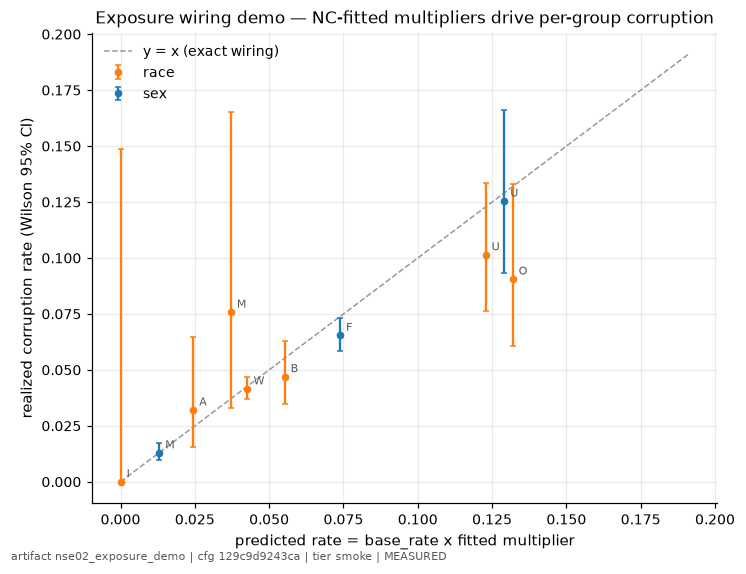

In [15]:
def draw_expo(ax, df, meta):
    colors = {"sex": "C0", "race": "C1"}
    top = 1.15 * float(max(df["predicted_rate"].max(), df["ci_high"].max()))
    ax.plot([0, top], [0, top], "--", color="0.6", linewidth=1, label="y = x (exact wiring)")
    for gcol, g in df.groupby("group_col", sort=True):
        for _, r in g.iterrows():
            ax.errorbar(
                r["predicted_rate"], r["realized_rate"],
                yerr=[[r["realized_rate"] - r["ci_low"]], [r["ci_high"] - r["realized_rate"]]],
                fmt="o", color=colors[gcol], capsize=2, markersize=4,
                label=gcol if r.name == g.index[0] else None,
            )
            ax.annotate(f"{r['group']}", (r["predicted_rate"], r["realized_rate"]),
                        textcoords="offset points", xytext=(4, 3), fontsize=7, color="0.35")
    ax.set_xlabel("predicted rate = base_rate x fitted multiplier")
    ax.set_ylabel("realized corruption rate (Wilson 95% CI)")
    ax.legend()


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="nse02_exposure_demo", draw=draw_expo,
    title="Exposure wiring demo — NC-fitted multipliers drive per-group corruption",
    figsize=(6.8, 5.2),
)

## 7. NSE-02: is the dirt faithful?

The scoring protocol, restated: pair every duplicate with its original, audit the pairs with
`noise.audit.classify_pair_diffs` (independent implementation — the generator is never
graded by its own code), fold `missing_gain/loss` into one `missing` bin (a generator can
only drop; the real mix carries both orientations), and compare each arm's per-field mix to
the NSE-01 measured mix by Jensen-Shannon divergence. The generic arm re-runs the *same*
base, duplicate structure, and seed, spending the same total edit budget on one uniform typo
channel over all five fields — the classic generic generator, budget-matched so the contest
is about *shape*, not amount. `dob` is audited for display but excluded from JS: NC has no
DOB, so there is no measured target for it (MET-06's identifiability point, felt here).

In [16]:
AUDIT_FIELDS = ["given_name", "family_name", "city", "zip", "dob"]
JS_FIELDS = ["given_name", "family_name", "city", "zip"]
MIX_CATS = ["identical", "missing", "typo", "nickname", "swap", "format_drift", "wholesale"]

t0 = time.time()
generic_rates = {"typo_uniform": GENERIC_TYPO_RATE}
generic_channels = {
    "typo_uniform": typo(fields=("given_name", "family_name", "city", "zip", "dob"))
}
with np.errstate(divide="ignore"):  # same benign gecko keymap divide as the calibrated arm
    corpus_gen, ops_gen = generate_corpus(
        base_full, channel_rates=generic_rates, channels=generic_channels,
        keep_original_rate=1.0, seed=PRIMARY_SEED,
    )
print(f"generic arm generated in {time.time() - t0:.1f}s: {len(corpus_gen):,} records, "
      f"{len(ops_gen):,} ops (uniform typo at the matched budget {GENERIC_TYPO_RATE:.6f})")


def build_aligned(arm_corpus: pd.DataFrame) -> pd.DataFrame:
    """(original, corrupted-duplicate) pairs as an align_pair-style frame, id-sorted."""
    dups = arm_corpus[arm_corpus["record_id"].str.contains("#dup")].copy()
    dups = dups.sort_values("record_id").reset_index(drop=True)  # undo the corpus shuffle
    dups["base_id"] = dups["record_id"].str.rsplit("#dup", n=1).str[0]
    lut = base_full.set_index("record_id")
    aligned = pd.DataFrame({"record_id": dups["record_id"].to_numpy()})
    for f in AUDIT_FIELDS:
        aligned[f + "_a"] = lut.loc[dups["base_id"], f].to_numpy()
        aligned[f + "_b"] = dups[f].to_numpy()
    return aligned.astype("string")


t0 = time.time()
aligned_cal = build_aligned(corpus)
aligned_gen = build_aligned(corpus_gen)
assert (aligned_cal["record_id"] == aligned_gen["record_id"]).all(), (
    "same seed must give both arms the identical duplicate structure"
)
long_cal = classify_pair_diffs(aligned_cal, fields=AUDIT_FIELDS, lexicon=lexicon,
                               key="record_id")
long_gen = classify_pair_diffs(aligned_gen, fields=AUDIT_FIELDS, lexicon=lexicon,
                               key="record_id")
n_pairs = len(aligned_cal)
print(f"audited {n_pairs:,} (original, duplicate) pairs x {len(AUDIT_FIELDS)} fields x 2 arms "
      f"in {time.time() - t0:.1f}s")


def real_mix_vec(field: str) -> pd.Series:
    vec = pd.Series(0.0, index=MIX_CATS)
    for _, r in prev[prev["field"] == field].iterrows():
        cat = str(r["category"])
        cat = "missing" if cat in ("missing_gain", "missing_loss") else cat
        vec[cat] += float(r["rate"])
    return vec


def arm_mix_vec(long_df: pd.DataFrame, field: str) -> pd.Series:
    vec = pd.Series(0.0, index=MIX_CATS)
    counts = long_df.loc[long_df["field"] == field, "category"].value_counts()
    for cat, k in counts.items():
        cat = "missing" if cat in ("missing_gain", "missing_loss") else str(cat)
        vec[cat] += int(k) / n_pairs
    return vec


mix_rows, js_rows = [], []
for f in JS_FIELDS + ["dob"]:
    vecs = {"calibrated": arm_mix_vec(long_cal, f), "generic": arm_mix_vec(long_gen, f)}
    if f in JS_FIELDS:
        vecs = {"real": real_mix_vec(f), **vecs}
    for arm, vec in vecs.items():
        for cat, rate in vec.items():
            mix_rows.append({"field": f, "arm": arm, "category": cat, "rate": float(rate)})
    if f in JS_FIELDS:
        for arm in ("calibrated", "generic"):
            js = float(jensenshannon(vecs["real"].to_numpy(), vecs[arm].to_numpy(),
                                     base=2) ** 2)
            js_rows.append({"field": f, "arm": arm, "js_bits": js})
mix_tbl = pd.DataFrame(mix_rows)
js_tbl = pd.DataFrame(js_rows)
registry.register(
    "nse02_category_mix", mix_tbl, cfg=cfg, tier=cfg.run.tier,
    meta={"n_pairs": int(n_pairs), "provenance": PREV_PROVENANCE, "caveat": CAVEAT,
          "note": "per-field diff-category mix: real (NSE-01, missing folded) vs the two "
                  "generated arms audited by er_lab.noise.audit; dob has no real target "
                  "(NC ships no DOB) and is excluded from JS"},
)
print("\nJS divergence to the measured mix (bits), per field:")
display(js_tbl.pivot(index="field", columns="arm", values="js_bits").loc[JS_FIELDS])
print("\ngenerated dob mix (no measured target — hub trap + generic typo land here):")
display(mix_tbl[(mix_tbl["field"] == "dob") & (mix_tbl["rate"] > 0)]
        .pivot(index="category", columns="arm", values="rate"))

generic arm generated in 0.3s: 32,259 records, 173 ops (uniform typo at the matched budget 0.012683)


audited 13,600 (original, duplicate) pairs x 5 fields x 2 arms in 0.6s

JS divergence to the measured mix (bits), per field:


arm,calibrated,generic
field,,
given_name,0.000066,0.000954
family_name,0.000078,0.001899
city,0.000340,0.003756
zip,0.004836,0.002607



generated dob mix (no measured target — hub trap + generic typo land here):


arm,calibrated,generic
category,,
format_drift,NaN,0.000368
identical,0.989265,0.998750
missing,0.001912,NaN
typo,0.000956,0.000882
wholesale,0.007868,NaN


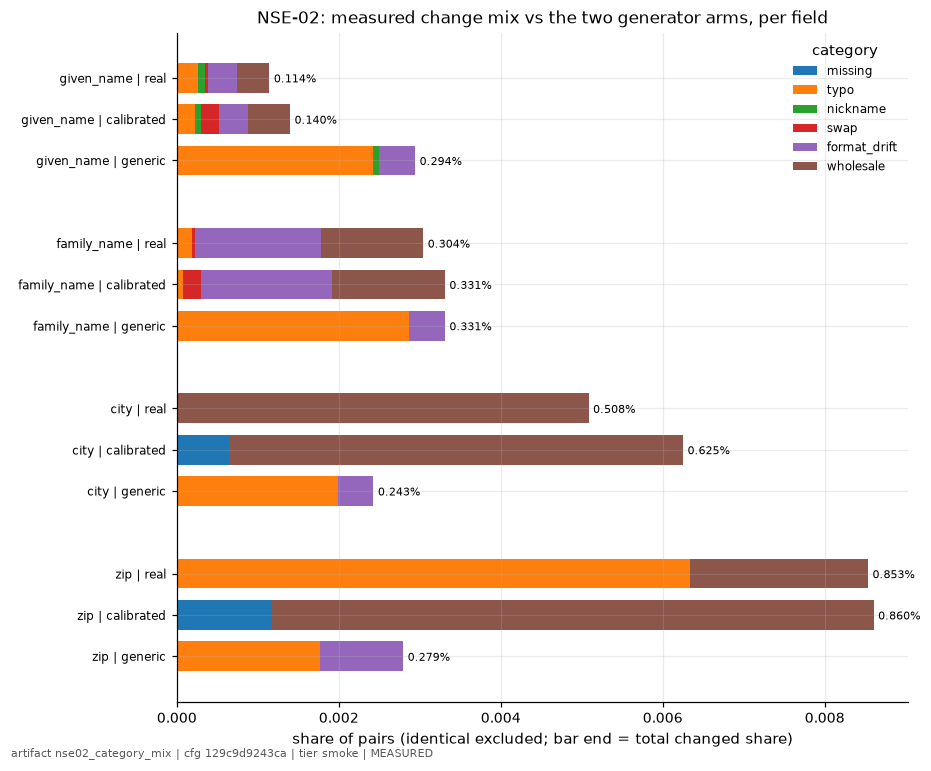

In [17]:
def draw_mix(ax, df, meta):
    arms = ["real", "calibrated", "generic"]
    cats = [c for c in MIX_CATS if c != "identical"]
    ypos, ylabels = [], []
    y = 0
    for f in JS_FIELDS:
        for arm in arms:
            left = 0.0
            for ci, cat in enumerate(cats):
                r = df[(df["field"] == f) & (df["arm"] == arm) & (df["category"] == cat)]
                v = float(r["rate"].iloc[0]) if len(r) else 0.0
                ax.barh(y, v, left=left, height=0.72, color=f"C{ci}",
                        label=cat if y == 0 else None)
                left += v
            ax.annotate(f"{left:.3%}", (left, y), textcoords="offset points",
                        xytext=(3, -3), fontsize=7)
            ypos.append(y)
            ylabels.append(f"{f} | {arm}")
            y += 1
        y += 1
    ax.set_yticks(ypos, ylabels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("share of pairs (identical excluded; bar end = total changed share)")
    ax.legend(loc="upper right", fontsize=8, title="category")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="nse02_category_mix", draw=draw_mix,
    title="NSE-02: measured change mix vs the two generator arms, per field",
    figsize=(8.5, 7.0),
)

### The acceptance criteria: does the corpus *look* like a real one?

PLAN §4's structural gates, scored against the NC snapshot (the newer of notebook 01's two,
county subset at this tier) with the thresholds pre-stated in §3. These criteria gauge the
**whole corpus** — base substrate plus generated noise — against a real administrative file:
a heavy-tailed surname distribution (Zipf tail slope), a realistic soundex-block profile
(what blocking will actually face), and name-collision mass (distinct people sharing exact
names — the irreducible-ambiguity floor MET-06 cares about). Honesty note before the
numbers: `historical_50k` is Wikidata-derived European-heavy historical figures, so
population-shape mismatches are expected findings about the *substrate*, not tunable dials —
which is exactly why they are scored rather than assumed. The NC snapshot contributes
anonymous aggregate curves only (ranks and shares — no name strings leave the computation).

In [18]:
creg, creg_meta = registry.load("corpus_registry", tier=cfg.run.tier)
nc_info = creg["nc_snapshots"]
snap_path = REPO_ROOT / nc_info["b"]["path"]
SNAP_DATE = str(nc_info["b"]["date"])
nc = pd.read_parquet(snap_path, columns=["given_name", "family_name", "ncid"])
print(f"NC comparison substrate: snapshot {SNAP_DATE}, {len(nc):,} records "
      f"(counties {nc_info['counties']}; aggregates only)")


def present(s: pd.Series) -> pd.Series:
    s = s.astype("string")
    return s.notna() & (s.str.strip() != "")


def freq_shares(s: pd.Series) -> np.ndarray:
    v = s[present(s)]
    return (v.value_counts().to_numpy(dtype=float)) / float(len(v))


def zipf_slope(shares: np.ndarray, r0: int = 10, r1: int = 1000) -> float:
    hi = min(r1, len(shares))
    ranks = np.arange(r0, hi + 1, dtype=float)
    return float(np.polyfit(np.log10(ranks), np.log10(shares[r0 - 1:hi]), 1)[0])


def soundex_shares(s: pd.Series) -> np.ndarray:
    v = s[present(s)].astype(str)
    codes = []
    for x in v:
        try:
            code = jellyfish.soundex(x.strip())
        except ValueError:
            continue
        if code and code.strip():
            codes.append(code)
    c = pd.Series(codes).value_counts().to_numpy(dtype=float)
    return c / c.sum()


def cross_entity_collision_mass(df: pd.DataFrame, name_cols: list[str],
                                entity_col: str) -> float:
    """P(two random records agree exactly on name_cols but belong to different entities)."""
    mask = np.ones(len(df), dtype=bool)
    for c in name_cols:
        mask &= present(df[c]).to_numpy()
    d = df.loc[mask, name_cols + [entity_col]]
    n = len(d)
    if n < 2:
        return float("nan")

    def pair_mass(sizes: pd.Series) -> float:
        a = sizes.to_numpy(dtype=float)
        return float((a * (a - 1)).sum() / 2.0)

    same_name = pair_mass(d.groupby(name_cols, observed=True).size())
    same_name_same_ent = pair_mass(d.groupby(name_cols + [entity_col], observed=True).size())
    return (same_name - same_name_same_ent) / (n * (n - 1) / 2.0)


t0 = time.time()
sur_gen, sur_nc = freq_shares(corpus["family_name"]), freq_shares(nc["family_name"])
slope_gen, slope_nc = zipf_slope(sur_gen), zipf_slope(sur_nc)
blk_gen, blk_nc = soundex_shares(corpus["family_name"]), soundex_shares(nc["family_name"])
block_mass_gen, block_mass_nc = float((blk_gen ** 2).sum()), float((blk_nc ** 2).sum())
block_max_gen, block_max_nc = float(blk_gen.max()), float(blk_nc.max())
coll_gen = cross_entity_collision_mass(corpus, ["given_name", "family_name"], "entity_id")
coll_nc = cross_entity_collision_mass(nc, ["given_name", "family_name"], "ncid")
allroles_gen = cross_entity_collision_mass(
    corpus, ["given_name", "family_name", "dob", "city", "zip"], "entity_id"
)
print(f"acceptance measurements computed in {time.time() - t0:.1f}s")

curve_rows = []
for curve, series in (("surname", {"calibrated_corpus": sur_gen, "nc_snapshot": sur_nc}),
                      ("soundex_block", {"calibrated_corpus": blk_gen, "nc_snapshot": blk_nc})):
    for corpus_name, shares in series.items():
        top = shares[:2000]
        for rank, share in enumerate(top, start=1):
            curve_rows.append({"curve": curve, "corpus": corpus_name,
                               "rank": rank, "share": float(share)})
curves = pd.DataFrame(curve_rows)
registry.register(
    "nse02_zipf_blocks", curves, cfg=cfg, tier=cfg.run.tier,
    meta={"note": "rank-share curves (top 2000), family_name frequencies and "
                  "soundex(family_name) block shares — anonymous aggregates only; "
                  f"NC side: snapshot {SNAP_DATE}, counties {nc_info['counties']}",
          "n_records": {"calibrated_corpus": len(corpus), "nc_snapshot": len(nc)}},
)


def ratio(a: float, b: float) -> float:
    return float(a / b) if b else float("nan")


def in_factor(r: float, factor: float) -> bool:
    return bool(np.isfinite(r) and (1.0 / factor) <= r <= factor)


score_rows = [
    {"metric": "js_divergence_bits", "scope": r["field"], "arm": r["arm"],
     "value": r["js_bits"], "threshold": np.nan, "passed": pd.NA,
     "note": "vs NSE-01 measured mix"} for r in js_rows
]
for arm in ("calibrated", "generic"):
    mean_js = float(js_tbl.loc[js_tbl["arm"] == arm, "js_bits"].mean())
    score_rows.append({"metric": "js_mean_bits", "scope": "mean(4 fields)", "arm": arm,
                       "value": mean_js, "threshold": np.nan, "passed": pd.NA,
                       "note": "unweighted mean over given/family/city/zip"})
acc_specs = [
    ("zipf_slope", "calibrated_corpus", slope_gen, np.nan, pd.NA, "log-log ranks 10..1000"),
    ("zipf_slope", "nc_snapshot", slope_nc, np.nan, pd.NA, "log-log ranks 10..1000"),
    ("zipf_slope_absdiff", "generated vs NC", abs(slope_gen - slope_nc),
     ACC_ZIPF_SLOPE_TOL, abs(slope_gen - slope_nc) <= ACC_ZIPF_SLOPE_TOL,
     "acceptance: |diff| <= threshold"),
    ("block_collision_mass", "calibrated_corpus", block_mass_gen, np.nan, pd.NA,
     "P(2 random records share a soundex(family) block)"),
    ("block_collision_mass", "nc_snapshot", block_mass_nc, np.nan, pd.NA, ""),
    ("block_collision_mass_ratio", "generated / NC", ratio(block_mass_gen, block_mass_nc),
     ACC_BLOCK_RATIO, in_factor(ratio(block_mass_gen, block_mass_nc), ACC_BLOCK_RATIO),
     "acceptance: within a factor of threshold"),
    ("block_max_share", "calibrated_corpus", block_max_gen, np.nan, pd.NA,
     "largest soundex block's share of records"),
    ("block_max_share", "nc_snapshot", block_max_nc, np.nan, pd.NA, ""),
    ("block_max_share_ratio", "generated / NC", ratio(block_max_gen, block_max_nc),
     ACC_BLOCK_RATIO, in_factor(ratio(block_max_gen, block_max_nc), ACC_BLOCK_RATIO),
     "acceptance: within a factor of threshold"),
    ("name_collision_mass", "calibrated_corpus", coll_gen, np.nan, pd.NA,
     "P(2 random records: same exact given+family, different entity)"),
    ("name_collision_mass", "nc_snapshot", coll_nc, np.nan, pd.NA,
     "different-ncid collisions"),
    ("name_collision_mass_ratio", "generated / NC", ratio(coll_gen, coll_nc),
     ACC_COLLISION_RATIO, in_factor(ratio(coll_gen, coll_nc), ACC_COLLISION_RATIO),
     "acceptance: within a factor of threshold"),
    ("allroles_collision_mass", "calibrated_corpus", allroles_gen, np.nan, pd.NA,
     ("cross-entity agreement on ALL of given/family/dob/city/zip — the corpus's own "
      "unresolvable floor (no NC counterpart: NC has no dob)")),
]
for m, s, v, t, p, nt in acc_specs:
    score_rows.append({"metric": m, "scope": s, "arm": "-", "value": float(v),
                       "threshold": float(t), "passed": p, "note": nt})
fidelity = pd.DataFrame(score_rows)
fidelity["passed"] = fidelity["passed"].map(
    lambda x: pd.NA if x is pd.NA else ("pass" if bool(x) else "FAIL")
).astype("string")
registry.register(
    "nse02_fidelity_scores", fidelity, cfg=cfg, tier=cfg.run.tier,
    meta={
        "provenance": PREV_PROVENANCE, "caveat": CAVEAT,
        "js_definition": "squared scipy jensenshannon (base 2) between per-field category "
                         "distributions incl. identical, missing folded",
        "arms": {"calibrated": "mapping-table rates", "generic": "uniform typo over 5 fields "
                 f"at the matched budget {GENERIC_TYPO_RATE:.6f}"},
        "acceptance_thresholds": {"zipf_slope_absdiff": ACC_ZIPF_SLOPE_TOL,
                                  "block_factor": ACC_BLOCK_RATIO,
                                  "collision_factor": ACC_COLLISION_RATIO},
        "nc_side": {"snapshot": SNAP_DATE, "counties": list(nc_info["counties"]),
                    "n_records": len(nc)},
        "n_pairs_audited": int(n_pairs),
    },
)
print(f"registered nse02_fidelity_scores: {len(fidelity)} rows")
display(fidelity)

NC comparison substrate: snapshot 20260101, 447,450 records (counties [68]; aggregates only)


acceptance measurements computed in 2.6s
registered nse02_fidelity_scores: 23 rows


,metric,scope,arm,value,threshold,passed,note
0,js_divergence_bits,given_name,calibrated,0.000066,NaN,<NA>,vs NSE-01 measured mix
1,js_divergence_bits,given_name,generic,0.000954,NaN,<NA>,vs NSE-01 measured mix
2,js_divergence_bits,family_name,calibrated,0.000078,NaN,<NA>,vs NSE-01 measured mix
3,js_divergence_bits,family_name,generic,0.001899,NaN,<NA>,vs NSE-01 measured mix
4,js_divergence_bits,city,calibrated,0.000340,NaN,<NA>,vs NSE-01 measured mix
5,js_divergence_bits,city,generic,0.003756,NaN,<NA>,vs NSE-01 measured mix
6,js_divergence_bits,zip,calibrated,0.004836,NaN,<NA>,vs NSE-01 measured mix
7,js_divergence_bits,zip,generic,0.002607,NaN,<NA>,vs NSE-01 measured mix
8,js_mean_bits,mean(4 fields),calibrated,0.001330,NaN,<NA>,unweighted mean over given/family/city/zip
9,js_mean_bits,mean(4 fields),generic,0.002304,NaN,<NA>,unweighted mean over given/family/city/zip


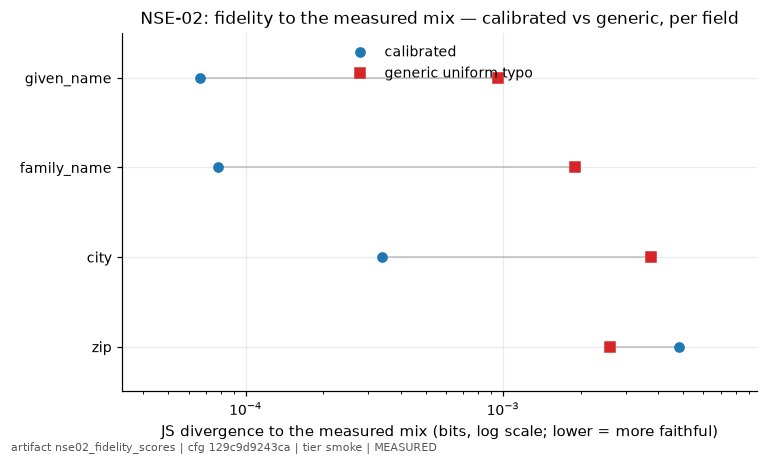

In [19]:
def draw_js(ax, df, meta):
    d = df[df["metric"] == "js_divergence_bits"]
    for i, f in enumerate(JS_FIELDS):
        cal = float(d[(d["scope"] == f) & (d["arm"] == "calibrated")]["value"].iloc[0])
        gen = float(d[(d["scope"] == f) & (d["arm"] == "generic")]["value"].iloc[0])
        ax.plot([cal, gen], [i, i], "-", color="0.75", linewidth=1, zorder=1)
        ax.plot(cal, i, "o", color="C0", label="calibrated" if i == 0 else None)
        ax.plot(gen, i, "s", color="C3", label="generic uniform typo" if i == 0 else None)
    ax.set_yticks(range(len(JS_FIELDS)), JS_FIELDS)
    ax.set_ylim(len(JS_FIELDS) - 0.5, -0.5)  # top-to-bottom, with headroom on both edges
    ax.set_xscale("log")
    vals = d["value"].to_numpy(dtype=float)
    ax.set_xlim(float(vals.min()) * 0.5, float(vals.max()) * 2.0)
    ax.set_xlabel("JS divergence to the measured mix (bits, log scale; lower = more faithful)")
    ax.legend(loc="upper center")


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="nse02_fidelity_scores", draw=draw_js,
    title="NSE-02: fidelity to the measured mix — calibrated vs generic, per field",
    figsize=(7.0, 4.2),
)

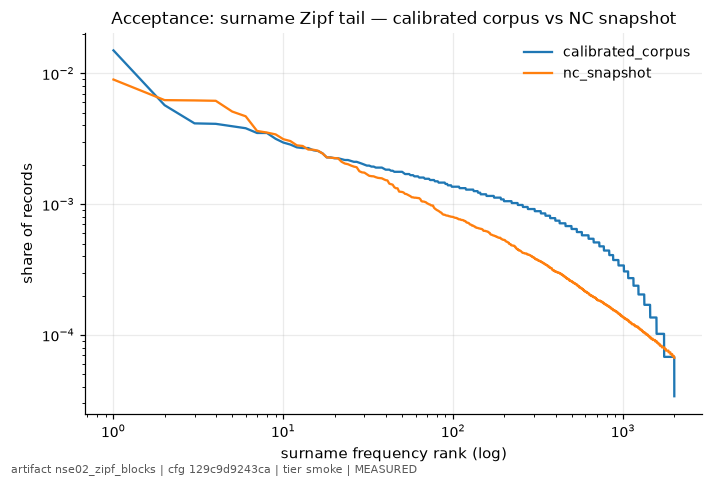

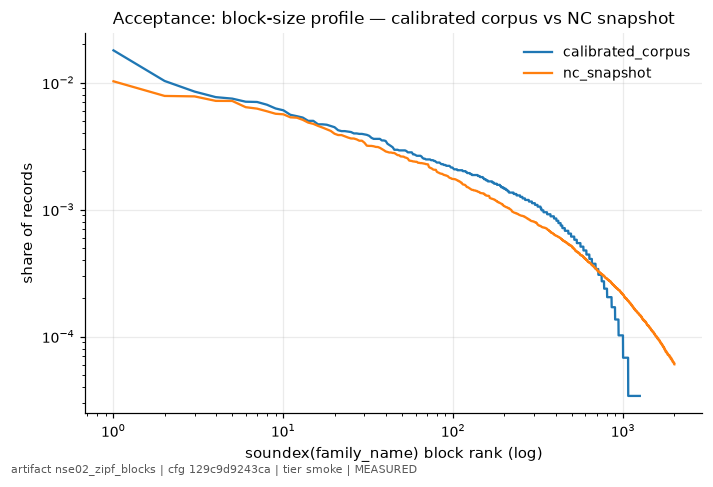

In [20]:
def draw_curve(curve_name, xlabel):
    def _draw(ax, df, meta):
        for corpus_name, g in df[df["curve"] == curve_name].groupby("corpus", sort=True):
            g = g.sort_values("rank")
            ax.plot(g["rank"], g["share"], label=corpus_name)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("share of records")
        ax.legend()
    return _draw


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="nse02_zipf_blocks",
    draw=draw_curve("surname", "surname frequency rank (log)"),
    title="Acceptance: surname Zipf tail — calibrated corpus vs NC snapshot",
    figsize=(6.5, 4.4),
)
fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="nse02_zipf_blocks",
    draw=draw_curve("soundex_block", "soundex(family_name) block rank (log)"),
    title="Acceptance: block-size profile — calibrated corpus vs NC snapshot",
    figsize=(6.5, 4.4),
)

### Verdict — scoring the NSE-02 card against the registered numbers

In [21]:
js_wide = js_tbl.pivot(index="field", columns="arm", values="js_bits")
wins = {f: bool(js_wide.loc[f, "calibrated"] < js_wide.loc[f, "generic"])
        for f in JS_FIELDS}
mean_cal = float(js_wide["calibrated"].mean())
mean_gen = float(js_wide["generic"].mean())
mean_win = bool(mean_cal < mean_gen)
named_ok = all(wins[f] for f in ("given_name", "family_name", "city"))
generic_beats = [f for f, w in wins.items() if not w]
acc = fidelity[fidelity["passed"].notna()]
acc_failed = [f"{r['metric']} ({r['scope']}: {r['value']:.4g} vs {r['threshold']:.4g})"
              for _, r in acc.iterrows() if r["passed"] == "FAIL"]
for f in JS_FIELDS:
    print(f"{f:>12}: JS calibrated {js_wide.loc[f, 'calibrated']:.2e} vs "
          f"generic {js_wide.loc[f, 'generic']:.2e} -> "
          f"{'calibrated wins' if wins[f] else 'GENERIC WINS'}")
print(f"{'mean':>12}: {mean_cal:.2e} vs {mean_gen:.2e} -> "
      f"{'calibrated wins' if mean_win else 'GENERIC WINS'}")
print(f"\nfields where generic beats calibrated: {generic_beats if generic_beats else 'none'}")
print(f"acceptance criteria failed: {acc_failed if acc_failed else 'none'}")

outcome = "CONFIRMED" if (named_ok and mean_win) else "REFUTED"
_ = verdict_box(
    "NSE-02",
    outcome=outcome,
    evidence=(
        f"nse02_fidelity_scores ({n_pairs:,} audited pairs, tier {TIER}): JS-to-measured-mix "
        f"(bits) calibrated vs generic — "
        + "; ".join(f"{f} {js_wide.loc[f, 'calibrated']:.2e} vs "
                    f"{js_wide.loc[f, 'generic']:.2e}" for f in JS_FIELDS)
        + f"; mean {mean_cal:.2e} vs {mean_gen:.2e}. Fields where the generic arm beats the "
        f"calibrated arm: {generic_beats if generic_beats else 'none'} (zip was pre-flagged "
        f"at-risk in the card; the audit's zip:typo bin encodes near-moves a pool redraw "
        f"cannot express). Acceptance criteria (pre-stated thresholds): "
        f"{'ALL PASS' if not acc_failed else 'FAILED -> ' + '; '.join(acc_failed)} — "
        f"Zipf slope {slope_gen:.2f} (corpus) vs {slope_nc:.2f} (NC {SNAP_DATE}); block "
        f"collision-mass ratio {ratio(block_mass_gen, block_mass_nc):.2f}; name "
        f"collision-mass ratio {ratio(coll_gen, coll_nc):.2f}. All under the NSE-01 caveat: "
        f"rates are two-year drift at scope '{AUDIT_SCOPE}', typo channels are lower bounds."
    ),
    registry=registry,
)

  given_name: JS calibrated 6.65e-05 vs generic 9.54e-04 -> calibrated wins
 family_name: JS calibrated 7.82e-05 vs generic 1.90e-03 -> calibrated wins
        city: JS calibrated 3.40e-04 vs generic 3.76e-03 -> calibrated wins
         zip: JS calibrated 4.84e-03 vs generic 2.61e-03 -> GENERIC WINS
        mean: 1.33e-03 vs 2.30e-03 -> calibrated wins

fields where generic beats calibrated: ['zip']
acceptance criteria failed: ['name_collision_mass_ratio (generated / NC: 84.43 vs 10)']


> ### VERDICT: CONFIRMED — card `NSE-02`
>
> **Conjecture** A generator whose channel dials are set from the NSE-01 measured per-field category mix produces same-entity pairs whose audited diff mix matches the real mix better than a budget-matched generic uniform-typo generator — the fidelity is measurable and the generic shortcut measurably fails.
>
> **Prediction** calibrated JS < generic JS on given_name, family_name, and city, and on the unweighted mean over the four compared fields. Pre-flagged risk: zip may go either way — the audit itself warns its zip:typo bin encodes near-moves (1-2 digit zip changes), which a value-pool redraw cannot express; losing zip alone does not refute the mix claim but must be reported. The structural acceptance criteria (Zipf slope within 0.5; block stats within 5x; collision mass within 10x of the NC snapshot) are scored alongside and may fail independently of the mix claim — they gauge the base corpus substrate as much as the noise.
>
> **Evidence** nse02_fidelity_scores (13,600 audited pairs, tier smoke): JS-to-measured-mix (bits) calibrated vs generic — given_name 6.65e-05 vs 9.54e-04; family_name 7.82e-05 vs 1.90e-03; city 3.40e-04 vs 3.76e-03; zip 4.84e-03 vs 2.61e-03; mean 1.33e-03 vs 2.30e-03. Fields where the generic arm beats the calibrated arm: ['zip'] (zip was pre-flagged at-risk in the card; the audit's zip:typo bin encodes near-moves a pool redraw cannot express). Acceptance criteria (pre-stated thresholds): FAILED -> name_collision_mass_ratio (generated / NC: 84.43 vs 10) — Zipf slope -0.52 (corpus) vs -0.74 (NC 20260101); block collision-mass ratio 1.46; name collision-mass ratio 84.43. All under the NSE-01 caveat: rates are two-year drift at scope 'county_subset_subsample', typo channels are lower bounds.


## 8. MET-07: splits that do not leak

The corpus now exists; the last deliverable is *how to split it*. Three schemes, registered
as `met07_splits` for every downstream training notebook:

- **random** — records shuffled and halved: the same entity (and household) sits on both
  sides of the train/eval boundary. This is the split most papers use.
- **entity-disjoint** — whole entities on one side only: what PLAN §5 mandates.
- **household-disjoint** — whole *households* (an entity plus the confusable trap that
  haunts it, via the corpus's `household_id`): stricter still, because a Jr/Sr pair split
  across the boundary silently removes the hardest negatives from eval.

The smoke demo then runs the tune/eval machinery with a deliberately capacity-starved
scorer: a single threshold on the untrained mean Jaro-Winkler score (over given/family/dob),
tuned on each scheme's train half, scored on its eval half — pairwise F1 over blocked
candidate pairs (three matchkey passes including a budgeted coarse surname-only pass, so the
candidate sets contain real negatives and the threshold is genuinely identified; per-record
budget k=25 bounds cost and keeps candidate budgets comparable across halves). One tuned
parameter can barely memorize anything, so this is the machinery's **negative control**: it
validates the harness (does the tuned threshold generalize within each scheme?) and reports
the cross-scheme optimism number with its known confound stated up front — random halves
*fragment* entities, which changes the positive-pair share of the blocked candidate sets, so
at this capacity the cross-scheme F1 difference reflects eval-set composition, not
memorization. The models that *can* leak arrive in notebooks 08–10, and the multi-seed
MET-07 verdict is the mid-tier rerun of these same cells (placard below).

In [22]:
GAP_CAP = 0.02  # per-scheme |train F1 - eval F1| bound for the null instrument (card P2)
_ = conjecture_card(
    card_id="MET-07",
    conjecture=(
        "Split design is a metrology decision, not bookkeeping: random record splits let the "
        "same entity and household sit on both sides of the tune/eval boundary (structural "
        "leakage), while entity- and household-disjoint splits remove it at increasing "
        "strictness; and with a scorer that has almost no capacity to memorize, the harness "
        "itself must manufacture no within-scheme optimism — so any optimism later measured "
        "for trained models is attributable to leakage-exploiting capacity, not to the "
        "machinery."
    ),
    pressure=(
        "the split scheme: random vs entity-disjoint vs household-disjoint halves of the "
        "calibrated corpus, with the scorer held fixed (untrained mean Jaro-Winkler over "
        "given_name/family_name/dob, one threshold tuned per train half)"
    ),
    property=(
        "structural leakage, counted exactly: entities (and households) with records on both "
        "sides of each scheme's boundary — plus the composition shift it induces (fragmented "
        "entities change the positive-pair share of blocked candidate sets)"
    ),
    metric=(
        "pairwise F1 over blocked candidate pairs (three matchkey passes incl. a budgeted "
        "coarse surname pass, per-record budget k=25) at the train-tuned threshold: "
        "per-scheme generalization gap = train F1 - eval F1, and optimism = eval_F1(random) "
        "- eval_F1(entity_disjoint), each side's positive-pair share alongside — registered "
        "in met07_split_demo"
    ),
    prediction=(
        "P1: the constructed splits are structurally sound — zero straddling entities under "
        "entity-disjoint, zero straddling households under household-disjoint, halves within "
        "45-55% of records, while the random split shows massive entity straddling (the leak "
        "made visible). P2: the one-parameter scorer generalizes within every scheme — "
        "|train F1 - eval F1| < 0.02 for all three — the harness is a valid null instrument. "
        "The cross-scheme optimism number is reported but pre-declared NOT interpretable as "
        "leakage at this capacity: random halves fragment entities and thereby shift the "
        "blocked-pair positive share, and that composition shift, not memorization, is "
        "expected to dominate its sign and size at smoke (one seed). The interpretable "
        "MET-07 optimism verdict — multi-seed, and with scorers that can memorize — is the "
        "mid-tier rerun of these cells plus the trained-model arms of notebooks 08-10."
    ),
    registry=registry,
)

### Conjecture card `MET-07`

| | |
|---|---|
| **Conjecture** | Split design is a metrology decision, not bookkeeping: random record splits let the same entity and household sit on both sides of the tune/eval boundary (structural leakage), while entity- and household-disjoint splits remove it at increasing strictness; and with a scorer that has almost no capacity to memorize, the harness itself must manufacture no within-scheme optimism — so any optimism later measured for trained models is attributable to leakage-exploiting capacity, not to the machinery. |
| **Pressure (dial)** | the split scheme: random vs entity-disjoint vs household-disjoint halves of the calibrated corpus, with the scorer held fixed (untrained mean Jaro-Winkler over given_name/family_name/dob, one threshold tuned per train half) |
| **Embedding property** | structural leakage, counted exactly: entities (and households) with records on both sides of each scheme's boundary — plus the composition shift it induces (fragmented entities change the positive-pair share of blocked candidate sets) |
| **System metric** | pairwise F1 over blocked candidate pairs (three matchkey passes incl. a budgeted coarse surname pass, per-record budget k=25) at the train-tuned threshold: per-scheme generalization gap = train F1 - eval F1, and optimism = eval_F1(random) - eval_F1(entity_disjoint), each side's positive-pair share alongside — registered in met07_split_demo |
| **Pre-registered prediction** | P1: the constructed splits are structurally sound — zero straddling entities under entity-disjoint, zero straddling households under household-disjoint, halves within 45-55% of records, while the random split shows massive entity straddling (the leak made visible). P2: the one-parameter scorer generalizes within every scheme — |train F1 - eval F1| < 0.02 for all three — the harness is a valid null instrument. The cross-scheme optimism number is reported but pre-declared NOT interpretable as leakage at this capacity: random halves fragment entities and thereby shift the blocked-pair positive share, and that composition shift, not memorization, is expected to dominate its sign and size at smoke (one seed). The interpretable MET-07 optimism verdict — multi-seed, and with scorers that can memorize — is the mid-tier rerun of these cells plus the trained-model arms of notebooks 08-10. |

*Immutable — sha256 `a77d6e445030`; registered before the affected runs, never edited (PLAN §5).*


In [23]:
def greedy_half(units: np.ndarray, sizes: pd.Series, rng: np.random.Generator) -> set:
    order = rng.permutation(len(units))
    total = int(sizes.sum())
    acc, train_units = 0, set()
    for i in order:
        train_units.add(units[i])
        acc += int(sizes[units[i]])
        if acc >= total // 2:
            break
    return train_units


def build_splits(seed: int) -> dict[str, tuple[set, set]]:
    rng_s = np.random.default_rng(seed)
    rid = corpus["record_id"].to_numpy()
    out: dict[str, tuple[set, set]] = {}
    perm = rng_s.permutation(len(rid))
    half = len(rid) // 2
    out["random"] = (set(rid[perm[:half]]), set(rid[perm[half:]]))
    for scheme, col in (("entity_disjoint", "entity_id"),
                        ("household_disjoint", "household_id")):
        sizes = corpus[col].value_counts()
        units = np.array(sorted(sizes.index))
        train_units = greedy_half(units, sizes, rng_s)
        mask = corpus[col].isin(train_units).to_numpy()
        out[scheme] = (set(rid[mask]), set(rid[~mask]))
    return out


def split_checks(splits: dict) -> dict:
    checks = {}
    for scheme, (train_ids, _) in splits.items():
        tagged = corpus.assign(s=corpus["record_id"].isin(train_ids))
        ent_straddle = int((tagged.groupby("entity_id", observed=True)["s"]
                            .nunique() > 1).sum())
        hh_straddle = int((tagged.groupby("household_id", observed=True)["s"]
                           .nunique() > 1).sum())
        checks[scheme] = {
            "train_share": float(tagged["s"].mean()),
            "entities_straddling": ent_straddle,
            "households_straddling": hh_straddle,
        }
    return checks


primary_splits = build_splits(PRIMARY_SEED)
checks = split_checks(primary_splits)
splits_ok = (
    checks["entity_disjoint"]["entities_straddling"] == 0
    and checks["household_disjoint"]["households_straddling"] == 0
    and all(0.45 <= c["train_share"] <= 0.55 for c in checks.values())
)
print("structural checks (the leak made visible):")
for scheme, c in checks.items():
    print(f"  {scheme:>18}: train share {c['train_share']:.1%}, "
          f"entities straddling {c['entities_straddling']:,}, "
          f"households straddling {c['households_straddling']:,}")
print(f"splits structurally sound: {splits_ok}")

registry.register(
    "met07_splits",
    {
        "schemes": {
            scheme: {"train": sorted(train_ids), "eval": sorted(eval_ids)}
            for scheme, (train_ids, eval_ids) in primary_splits.items()
        },
        "metadata": {
            "seed": PRIMARY_SEED,
            "n_records": len(corpus),
            "corpus_artifact": "calibrated_corpus",
            "household_definition": (
                "household_id column of calibrated_corpus: entity_id, except "
                "household-confusable entities map to the base entity they haunt"
            ),
            "checks": checks,
            "protocol": "no entity (household) appears on both sides of the "
                        "entity-disjoint (household-disjoint) train/eval boundary (PLAN §5)",
        },
    },
    cfg=cfg, tier=cfg.run.tier,
    meta={"note": "record_id index sets per scheme; see payload metadata for checks",
          "seed": PRIMARY_SEED},
)
print(f"registered met07_splits: 3 schemes x train/eval over {len(corpus):,} records")

structural checks (the leak made visible):
              random: train share 50.0%, entities straddling 1,911, households straddling 1,809
     entity_disjoint: train share 50.1%, entities straddling 0, households straddling 290
  household_disjoint: train share 50.0%, entities straddling 0, households straddling 0
splits structurally sound: True
registered met07_splits: 3 schemes x train/eval over 32,259 records


### The optimism demo — tune on train, score on eval, one scheme at a time

In [24]:
SCORE_FIELDS = ["given_name", "family_name", "dob"]
DEMO_PASSES = [["soundex(family_name)", "year(dob)"], ["zip", "initial(given_name)"],
               ["soundex(family_name)"]]  # two precise passes + a coarse negatives source
DEMO_BUDGET_K = 25  # per-record candidate budget: bounds cost, comparable across halves


def jw_col(x: pd.Series, y: pd.Series) -> np.ndarray:
    out = np.full(len(x), np.nan)
    for i, (u, v) in enumerate(zip(x, y)):
        if not (pd.isna(u) or pd.isna(v)):
            out[i] = jellyfish.jaro_winkler_similarity(str(u), str(v))
    return out


def pair_scores_labels(sdf: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    cand = matchkeys.candidates(sdf, passes=DEMO_PASSES, budget_k=DEMO_BUDGET_K)
    lut = sdf.set_index("record_id")[SCORE_FIELDS]
    ent = sdf.set_index("record_id")["entity_id"]
    left = lut.loc[cand["a"]].reset_index(drop=True)
    right = lut.loc[cand["b"]].reset_index(drop=True)
    sim = np.column_stack([jw_col(left[f], right[f]) for f in SCORE_FIELDS])
    n_valid = (~np.isnan(sim)).sum(axis=1)
    scores = np.where(n_valid > 0, np.nansum(sim, axis=1) / np.maximum(n_valid, 1), 0.0)
    labels = ent.loc[cand["a"]].to_numpy() == ent.loc[cand["b"]].to_numpy()
    return scores, labels.astype(bool)


def tune_threshold(scores: np.ndarray, labels: np.ndarray) -> tuple[float, float]:
    """Threshold maximizing pairwise F1 on (scores, labels); returns (threshold, best F1)."""
    order = np.argsort(-scores, kind="stable")
    s, y = scores[order], labels[order].astype(float)
    tp, fp = np.cumsum(y), np.cumsum(1.0 - y)
    pos = max(float(y.sum()), 1e-12)
    prec = tp / np.maximum(tp + fp, 1e-12)
    rec = tp / pos
    f1 = np.where(prec + rec > 0, 2 * prec * rec / np.maximum(prec + rec, 1e-12), 0.0)
    cut = np.flatnonzero(np.r_[np.diff(s) != 0, True])  # last index of each distinct score
    best = cut[int(np.argmax(f1[cut]))]
    return float(s[best]), float(f1[best])


def f1_at(scores: np.ndarray, labels: np.ndarray, thr: float) -> float:
    pred = scores >= thr
    tp = float(np.sum(pred & labels))
    fp = float(np.sum(pred & ~labels))
    fn = float(np.sum(~pred & labels))
    if tp + fp == 0 or tp + fn == 0:
        return float("nan")
    prec, rec = tp / (tp + fp), tp / (tp + fn)
    return 2 * prec * rec / (prec + rec) if prec + rec else 0.0


t0 = time.time()
demo_rows = []
for seed in SEEDS_DEMO:
    splits = primary_splits if seed == PRIMARY_SEED else build_splits(seed)
    for scheme, (train_ids, eval_ids) in splits.items():
        sides = {}
        for side_name, ids in (("train", train_ids), ("eval", eval_ids)):
            sdf = corpus[corpus["record_id"].isin(ids)].reset_index(drop=True)
            sides[side_name] = (sdf, *pair_scores_labels(sdf))
        thr, train_f1 = tune_threshold(sides["train"][1], sides["train"][2])
        eval_f1 = f1_at(sides["eval"][1], sides["eval"][2], thr)
        demo_rows.append({
            "seed": int(seed), "scheme": scheme, "threshold": thr,
            "train_f1": train_f1, "eval_f1": eval_f1,
            "n_train_records": len(sides["train"][0]),
            "n_eval_records": len(sides["eval"][0]),
            "n_train_pairs": len(sides["train"][1]),
            "n_eval_pairs": len(sides["eval"][1]),
            "train_pos_share": float(sides["train"][2].mean()),
            "eval_pos_share": float(sides["eval"][2].mean()),
        })
demo_secs = time.time() - t0
demo = pd.DataFrame(demo_rows)
registry.register(
    "met07_split_demo", demo, cfg=cfg, tier=cfg.run.tier,
    meta={
        "scorer": "untrained mean Jaro-Winkler over given_name/family_name/dob "
                  "(capacity-starved negative control); pairwise F1 over blocked candidate "
                  "pairs only",
        "blocking": {"passes": DEMO_PASSES, "budget_k": DEMO_BUDGET_K},
        "seeds": [int(s) for s in SEEDS_DEMO],
        "protocol": "threshold tuned on the train half only, scored once on the eval half — "
                    "never per-method best-F1 on eval (MET-02)",
        "optimism": "eval_f1(random) - eval_f1(entity_disjoint), per seed — see the card: "
                    "NOT interpretable as leakage at this capacity (composition confound; "
                    "the pos-share columns quantify it)",
    },
)
print(f"split demo ({len(SEEDS_DEMO)} seed(s) x 3 schemes x 2 sides) in {demo_secs:.1f}s")
display(demo)

split demo (1 seed(s) x 3 schemes x 2 sides) in 6.8s


,seed,scheme,threshold,train_f1,eval_f1,n_train_records,n_eval_records,n_train_pairs,n_eval_pairs,train_pos_share,eval_pos_share
0,17,random,0.808095,0.922887,0.919973,16129,16130,133494,132408,0.526556,0.517318
1,17,entity_disjoint,0.782778,0.953947,0.953704,16164,16095,149140,145669,0.777337,0.768187
2,17,household_disjoint,0.794226,0.951903,0.946652,16137,16122,149935,148029,0.756048,0.766309


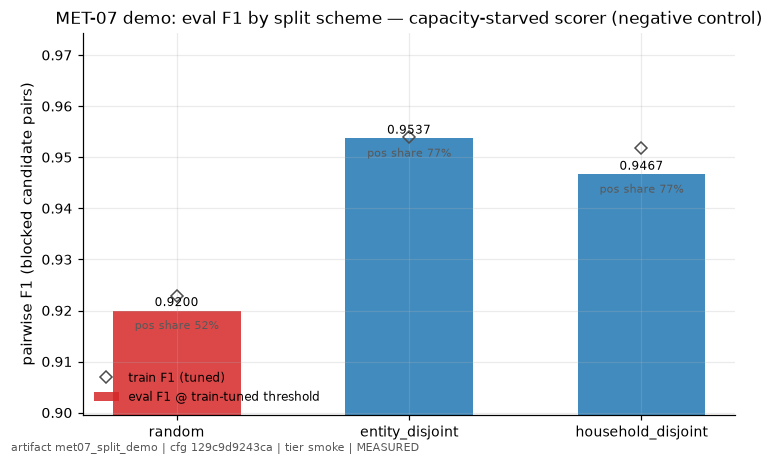

In [25]:
def draw_split(ax, df, meta):
    d = df[df["seed"] == int(df["seed"].iloc[0])]
    order = ["random", "entity_disjoint", "household_disjoint"]
    d = d.set_index("scheme").loc[order]
    x = np.arange(len(order))
    ax.bar(x, d["eval_f1"], width=0.55, color=["C3", "C0", "C0"], alpha=0.85,
           label="eval F1 @ train-tuned threshold")
    ax.plot(x, d["train_f1"], "D", markerfacecolor="none", color="0.3",
            label="train F1 (tuned)")
    for i, v in enumerate(d["eval_f1"]):
        ax.annotate(f"{v:.4f}", (x[i], v), textcoords="offset points", xytext=(0, 3),
                    ha="center", fontsize=8)
        ax.annotate(f"pos share {d['eval_pos_share'].iloc[i]:.0%}", (x[i], v),
                    textcoords="offset points", xytext=(0, -12), ha="center", fontsize=7,
                    color="0.35")
    lo = float(min(d["eval_f1"].min(), d["train_f1"].min()))
    hi = float(max(d["eval_f1"].max(), d["train_f1"].max()))
    pad = max((hi - lo) * 0.6, 0.005)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xticks(x, order)
    ax.set_ylabel("pairwise F1 (blocked candidate pairs)")
    ax.legend(loc="lower left", fontsize=8)


fig = figures.plot_artifact(
    registry, tier=cfg.run.tier, artifact="met07_split_demo", draw=draw_split,
    title="MET-07 demo: eval F1 by split scheme — capacity-starved scorer (negative control)",
    figsize=(6.8, 4.2),
)

In [26]:
# [RUN-IN-TARGET mac] definitive MET-07: multi-seed split-optimism at tier=mid on the mac —
# same cells, run.seeds list, full 50k-base corpus; the trained-scorer optimism arms land in
# notebooks 08-10 on top of these same registered splits.
if TIER in ("mid", "target"):
    print(f"tier={TIER}: the demo above ran seeds {SEEDS_DEMO} on the full-corpus splits — "
          "these ARE the definitive untrained-scorer MET-07 numbers; the trained-scorer "
          "optimism verdicts build on them in notebooks 08-10.")
else:
    scale = (len(hist_full) / max(len(base), 1)) * (len(list(cfg.run.seeds)) / 1.0)
    print(f"[RUN-IN-TARGET mac] the definitive MET-07 numbers come from rerunning THESE cells "
          f"at tier=mid on the mac: full corpus x seeds {[int(s) for s in cfg.run.seeds]}. "
          f"This run's demo took {demo_secs:.0f}s at {len(corpus):,} records x 1 seed; a "
          f"naive linear scaling ({scale:.1f}x) suggests ~{demo_secs * scale / 60:.0f} min, "
          "and block growth makes that a lower bound. At smoke the numbers above are a "
          "single-seed negative control, not the MET-07 verdict.")

[RUN-IN-TARGET mac] the definitive MET-07 numbers come from rerunning THESE cells at tier=mid on the mac: full corpus x seeds [17, 23, 29]. This run's demo took 7s at 32,259 records x 1 seed; a naive linear scaling (8.4x) suggests ~1 min, and block growth makes that a lower bound. At smoke the numbers above are a single-seed negative control, not the MET-07 verdict.


### Verdict — scoring the MET-07 card against the demo numbers

In [27]:
per_seed = demo.pivot(index="seed", columns="scheme", values="eval_f1")
optimism = (per_seed["random"] - per_seed["entity_disjoint"]).to_numpy(dtype=float)
hh_delta = (per_seed["household_disjoint"] - per_seed["entity_disjoint"]).to_numpy(dtype=float)
mean_opt = float(np.mean(optimism))
demo["gap"] = demo["train_f1"] - demo["eval_f1"]
max_gap = float(demo["gap"].abs().max())
pos_share = {r["scheme"]: float(r["eval_pos_share"])
             for _, r in demo[demo["seed"] == PRIMARY_SEED].iterrows()}
p1 = bool(splits_ok and checks["random"]["entities_straddling"] > 0)
p2 = bool(max_gap < GAP_CAP)
print("per-scheme generalization gap (train F1 - eval F1), all seeds:")
for _, r in demo.iterrows():
    print(f"  seed {int(r['seed'])} {r['scheme']:>18}: {r['gap']:+.4f} "
          f"(eval pos share {r['eval_pos_share']:.1%})")
print(f"\noptimism per seed (random - entity_disjoint eval F1): "
      f"{[f'{v:+.4f}' for v in optimism]} (mean {mean_opt:+.4f})")
print(f"household_disjoint - entity_disjoint eval F1: {[f'{v:+.4f}' for v in hh_delta]}")
print("reading per the card: the optimism number rides on the eval-set composition shift "
      "visible in the pos-share column (random halves fragment entities), NOT on "
      "memorization — the interpretable optimism verdict is mid-tier with trained scorers.")
print(f"\nP1 (splits sound + random leaks structurally): {p1}")
print(f"P2 (max per-scheme |train-eval| gap {max_gap:.4f} < {GAP_CAP}): {p2}")

outcome = "CONFIRMED" if (p1 and p2) else "REFUTED"
if TIER in ("mid", "target"):
    scope_note = "multi-seed run at this tier"
else:
    scope_note = ("single-seed smoke negative control — the multi-seed mid-tier rerun and "
                  "the trained-model arms (NB08-10) carry the definitive MET-07 verdict")
_ = verdict_box(
    "MET-07",
    outcome=outcome,
    evidence=(
        f"met07_splits checks: entity_disjoint straddling entities = "
        f"{checks['entity_disjoint']['entities_straddling']}, household_disjoint straddling "
        f"households = {checks['household_disjoint']['households_straddling']}, random-split "
        f"straddling entities = {checks['random']['entities_straddling']:,} of "
        f"{corpus['entity_id'].nunique():,} (the structural leak), train shares "
        + ", ".join(f"{s} {c['train_share']:.1%}" for s, c in checks.items())
        + f". met07_split_demo (seeds {[int(s) for s in SEEDS_DEMO]}, untrained JW-mean "
        f"scorer, blocked-pairs F1): eval F1 "
        + ", ".join(f"{s} {per_seed[s].iloc[0]:.4f} (pos share {pos_share[s]:.1%})"
                    for s in ("random", "entity_disjoint", "household_disjoint"))
        + f"; max per-scheme |train-eval| gap {max_gap:.4f} vs pre-stated cap {GAP_CAP} -> "
        f"P2 {p2}. Reported optimism (random - entity_disjoint eval F1): mean {mean_opt:+.4f} "
        f"— per the card, at this capacity it tracks the eval-set composition shift (the "
        f"pos-share spread above), not leakage. Scope: {scope_note}."
    ),
    registry=registry,
)

per-scheme generalization gap (train F1 - eval F1), all seeds:
  seed 17             random: +0.0029 (eval pos share 51.7%)
  seed 17    entity_disjoint: +0.0002 (eval pos share 76.8%)
  seed 17 household_disjoint: +0.0053 (eval pos share 76.6%)

optimism per seed (random - entity_disjoint eval F1): ['-0.0337'] (mean -0.0337)
household_disjoint - entity_disjoint eval F1: ['-0.0071']
reading per the card: the optimism number rides on the eval-set composition shift visible in the pos-share column (random halves fragment entities), NOT on memorization — the interpretable optimism verdict is mid-tier with trained scorers.

P1 (splits sound + random leaks structurally): True
P2 (max per-scheme |train-eval| gap 0.0053 < 0.02): True


> ### VERDICT: CONFIRMED — card `MET-07`
>
> **Conjecture** Split design is a metrology decision, not bookkeeping: random record splits let the same entity and household sit on both sides of the tune/eval boundary (structural leakage), while entity- and household-disjoint splits remove it at increasing strictness; and with a scorer that has almost no capacity to memorize, the harness itself must manufacture no within-scheme optimism — so any optimism later measured for trained models is attributable to leakage-exploiting capacity, not to the machinery.
>
> **Prediction** P1: the constructed splits are structurally sound — zero straddling entities under entity-disjoint, zero straddling households under household-disjoint, halves within 45-55% of records, while the random split shows massive entity straddling (the leak made visible). P2: the one-parameter scorer generalizes within every scheme — |train F1 - eval F1| < 0.02 for all three — the harness is a valid null instrument. The cross-scheme optimism number is reported but pre-declared NOT interpretable as leakage at this capacity: random halves fragment entities and thereby shift the blocked-pair positive share, and that composition shift, not memorization, is expected to dominate its sign and size at smoke (one seed). The interpretable MET-07 optimism verdict — multi-seed, and with scorers that can memorize — is the mid-tier rerun of these cells plus the trained-model arms of notebooks 08-10.
>
> **Evidence** met07_splits checks: entity_disjoint straddling entities = 0, household_disjoint straddling households = 0, random-split straddling entities = 1,911 of 2,507 (the structural leak), train shares random 50.0%, entity_disjoint 50.1%, household_disjoint 50.0%. met07_split_demo (seeds [17], untrained JW-mean scorer, blocked-pairs F1): eval F1 random 0.9200 (pos share 51.7%), entity_disjoint 0.9537 (pos share 76.8%), household_disjoint 0.9467 (pos share 76.6%); max per-scheme |train-eval| gap 0.0053 vs pre-stated cap 0.02 -> P2 True. Reported optimism (random - entity_disjoint eval F1): mean -0.0337 — per the card, at this capacity it tracks the eval-set composition shift (the pos-share spread above), not leakage. Scope: single-seed smoke negative control — the multi-seed mid-tier rerun and the trained-model arms (NB08-10) carry the definitive MET-07 verdict.


## What the calibrated corpus promises downstream

The contract, qualitatively (every number lives in the registered artifacts):

- **`calibrated_corpus`** is the lab's controlled-experiment substrate from notebook 06
  onward: perfect entity labels by construction, noise at measured rates with printed
  provenance, traps (households, hubs) at generic-labeled rates, and a `household_id`
  column so household structure never has to be re-derived. Its meta carries the NSE-01
  caveat, the lower-bound status of the typo channels, and the uniform-exposure decision
  with its reason.
- **`calibrated_corpus_ops`** is the ground-truth mutation log — TRN-03's mediation
  analysis and any slice-level scoring (which pairs carry which noise) read it instead of
  re-diffing records.
- **`nse02_fidelity_scores`** is the standing fidelity scoreboard: the JS margins are the
  evidence that calibration bought something real, and the acceptance rows record exactly
  where the substrate does and does not resemble a real administrative file. NSE-03
  (notebook 14) asks whether the rankings even care; notebook 18 re-runs this scoring when
  the machine is re-calibrated to a new corpus.
- **`met07_splits`** is binding: every training notebook draws its train/eval boundaries
  from here (PLAN §5 — no entity on both sides), and the household-disjoint scheme exists
  precisely so the Jr/Sr traps stay adversarial in eval.

## What we now know

- **Every dial in the dirt machine now has a printed pedigree.** The mapping table
  (`calibrated_channel_rates`) traces each channel rate to named cells of
  `nse01_channel_prevalence`, states every aggregation rule (joint-move decomposition, swap
  double-count, missing fold), and labels what is measured, what is a generic trap, and
  what is unmeasurable-here (OCR/phonetic — invisible to a two-snapshot diff). Typo rates
  are carried as measured *lower bounds*, deliberately diverging from a generic-defaults
  fallback so that nothing in the corpus is folklore; the generic dose is TRN-03's
  experimental dial, not a buried constant.
- **Calibration beats budget-matched folklore where the card said it would** — the
  per-field JS margins and the zip weak spot are in `nse02_fidelity_scores` and the verdict
  box above, including any field where the generic arm won.
- **The measured truth about two-year drift is mostly silence**: the overwhelming majority
  of calibrated duplicates are exact copies, because that is what the audit measured. The
  hard variation in the corpus comes from the base corpus's native variants plus the traps —
  a substrate shaped like reality rather than like a benchmark generator's defaults.
- **Exposure is wired but honestly withheld from this corpus**: historical_50k cannot carry
  NCSBE-coded group multipliers (no race/ethnicity; incompatible, noisy sex coding), so the
  corpus meta says `uniform`, and the wiring is demonstrated end-to-end on an NC-derived
  synthetic block (`nse02_exposure_demo`) — realized per-group rates tracking
  base×multiplier — with no NC record-level data involved.
- **The splits exist, are structurally verified, and the harness is a valid null
  instrument** — with one methodological finding worth its own sentence: for a scorer that
  cannot memorize, the naive cross-scheme "optimism" number is dominated by an eval-set
  composition shift (random halves fragment entities and change the blocked-pair positive
  share, visible in `met07_split_demo`'s pos-share columns), which is precisely why MET-07's
  real optimism claim requires trained scorers, multiple seeds, and the mid-tier rerun —
  and why the demo's pre-registered check is the within-scheme generalization gap instead.
- **Package limitations worked around in-notebook, on the record**: `load_lexicon` still
  mis-parses the drifted upstream names.csv (notebook 04's workaround, reapplied);
  `household_confusables` gates on a street column this corpus lacks (city aliased in as
  the locality role, dropped after); the package channels do not maintain `full_name`
  consistency, so the wholesale name-change channel and the household edits sync it
  in-notebook (documented stale-mass exception for typo/nickname/swap).

**Artifacts registered** (exact names): `calibrated_corpus`, `nse02_fidelity_scores`,
`met07_splits` — plus supporting `calibrated_corpus_ops`, `calibrated_channel_rates`,
`nse02_category_mix`, `nse02_zipf_blocks`, `nse02_exposure_demo`, `met07_split_demo`, and
the immutable cards `card_NSE-02`, `card_MET-07`.

In [28]:
print(f"notebook wall-clock: {time.time() - NB_T0:.0f}s")

notebook wall-clock: 14s
